Lead Scoring Study(problems statement and goal)

X-Education is an education company sells online education courses to professionals and advertisesit on the website and search enginee. Company get the data and indetify the leads and it conversion. From the collected data and inferences the converon leads is very low , about 30%. Company wishes to identifying Hot Leads i.e the most potential leads,also it want to achieve 80% of the visit and enrollment.

-Goals of the Case Study-


Building logistics regression model to finding lead score between 0 and 100 for Company and help to achieve potential targets 'Hot leads'.
For a futuristic changes the model should be ready an flexible to accomamdate the and predict the outcome.






Step-1: Data reading and identifiction

In [1]:
# suppresing warning:
import warnings
warnings.filterwarnings("ignore")

In [2]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Set_option to  limit truncation of column and rows
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [4]:
#Reding of data 'Leads' as 'leads_df'
leads_df=pd.read_csv(r"C:\Users\user\Desktop\Upgarde excell course\Courses\Lead score case study\Lead Scoring Assignment\Leads.csv")

In [5]:
#Displyaing heads 
leads_df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,NaN,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Select,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Not Sure,No,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Select,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [6]:
#chekong first five column
leads_df.shape

(9240, 37)

In [7]:
#Checking statistical data
leads_df.describe()

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.000000,9240.000000,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,617188.435606,0.385390,3.445238,487.698268,2.362820,14.306252,16.344883
std,23405.995698,0.486714,4.854853,548.021466,2.161418,1.386694,1.811395
min,579533.000000,0.000000,0.000000,0.000000,0.000000,7.000000,11.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000,14.000000,15.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000,14.000000,16.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000,15.000000,18.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000,18.000000,20.000000


In [8]:
#checking the info
leads_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

Observation:
 from the statistical outcome  it can be comprehand that column 'TotalVisits','Total Time Spent on Website','Page Views Per Visit' having large differences in some the indicating parameters such as of  significant difference between min and max values.We can further explore the skewness in by EDA.

Step-2:  Data cleaning and check

In [9]:
# data type
leads_df.dtypes

Prospect ID                                       object
Lead Number                                        int64
Lead Origin                                       object
Lead Source                                       object
Do Not Email                                      object
Do Not Call                                       object
Converted                                          int64
TotalVisits                                      float64
Total Time Spent on Website                        int64
Page Views Per Visit                             float64
Last Activity                                     object
Country                                           object
Specialization                                    object
How did you hear about X Education                object
What is your current occupation                   object
What matters most to you in choosing a course     object
Search                                            object
Magazine                       

Observation: as from the above data type output no iiirgularity iis obsereved and out 37 dtype , 7 are numerical(4 float and 3 integer)

In [10]:
# checking for repetion i.e duplicate values and droping
leads_df.drop_duplicates(subset=None,inplace=True )

In [11]:
#checking column attribute and shape after droping duplicate
leads_df.shape

(9240, 37)

Observation: No duplicate observed as shape in intact

Concern:  as from the head output we obseve that some of the columns has attributes as "Select" which indicate that  visitior has not selected its option while filling the form , so it wolud be better to replace it with null values

In [12]:
# slecting column with 'Select vlue ' using for loop.
cols=list(leads_df.columns)
for i in cols:
    if 'Select' in leads_df[i].values:
        print(i)

Specialization
How did you hear about X Education
Lead Profile
City


In [13]:
#Replacing the above columns having select attribute with null value
leads_df=leads_df.replace('Select', np.nan)

In [14]:
#After replacing with null value checking the status of column
cols=list(leads_df.columns)
for i in cols:
    if 'Select' in leads_df[i].values:
        print(i)

NO Select attribute in any of the columns

In [15]:
# checking null/missing values
leads_df.isnull().sum()


Prospect ID                                         0
Lead Number                                         0
Lead Origin                                         0
Lead Source                                        36
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                       137
Total Time Spent on Website                         0
Page Views Per Visit                              137
Last Activity                                     103
Country                                          2461
Specialization                                   3380
How did you hear about X Education               7250
What is your current occupation                  2690
What matters most to you in choosing a course    2709
Search                                              0
Magazine                                            0
Newspaper Article           

In [16]:
#converting to percentage null value upto 2 digit
round(100*(leads_df.isnull().sum()/len(leads_df)),2)

Prospect ID                                       0.00
Lead Number                                       0.00
Lead Origin                                       0.00
Lead Source                                       0.39
Do Not Email                                      0.00
Do Not Call                                       0.00
Converted                                         0.00
TotalVisits                                       1.48
Total Time Spent on Website                       0.00
Page Views Per Visit                              1.48
Last Activity                                     1.11
Country                                          26.63
Specialization                                   36.58
How did you hear about X Education               78.46
What is your current occupation                  29.11
What matters most to you in choosing a course    29.32
Search                                            0.00
Magazine                                          0.00
Newspaper 

Observation:
from the above output , nos of column are having more than 30% missing value , we should consider droping it as it may be baised leading to misinterpretation of the data
colums such as:
coloumns having missing value ~45% and these columns are assigned by sales team after call:-
    Asymmetrique Activity Index,
    Asymmetrique Profile Index,
    Asymmetrique Activity Score,
    Asymmetrique Profile Score,
    
How did you hear about X Education,
Lead Profile, columns having more than 70% missing values so better to drop them.

-Lead Quality having ~51% missing values so we can drop it.

City column having ~39% missing values and if we will impute mode or most frequent value for missing value then our data will be some what biased.So better to drop it.

In [17]:
#listing all the column with missing values more than 30%
missing_columns_30 =leads_df.columns[100*(leads_df.isnull().sum()/len(leads_df)) > 30]
print(missing_columns_30)

Index(['Specialization', 'How did you hear about X Education', 'Tags', 'Lead Quality', 'Lead Profile', 'City', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score'], dtype='object')


In [18]:
#Droping missing column
miss_cols= missing_columns_30.drop('Specialization')


In [19]:
#creating copy of original datafram and checking missing value in new data frame
leads_df2= leads_df.copy()

In [20]:
#droping cloumns with more than 30% missing values
leads_df2 = leads_df2.drop(miss_cols, axis=1).copy()


In [21]:
#checking for other columns with missing values
round(100*(leads_df2.isnull().sum()/len(leads_df2)),2)

Prospect ID                                       0.00
Lead Number                                       0.00
Lead Origin                                       0.00
Lead Source                                       0.39
Do Not Email                                      0.00
Do Not Call                                       0.00
Converted                                         0.00
TotalVisits                                       1.48
Total Time Spent on Website                       0.00
Page Views Per Visit                              1.48
Last Activity                                     1.11
Country                                          26.63
Specialization                                   36.58
What is your current occupation                  29.11
What matters most to you in choosing a course    29.32
Search                                            0.00
Magazine                                          0.00
Newspaper Article                                 0.00
X Educatio

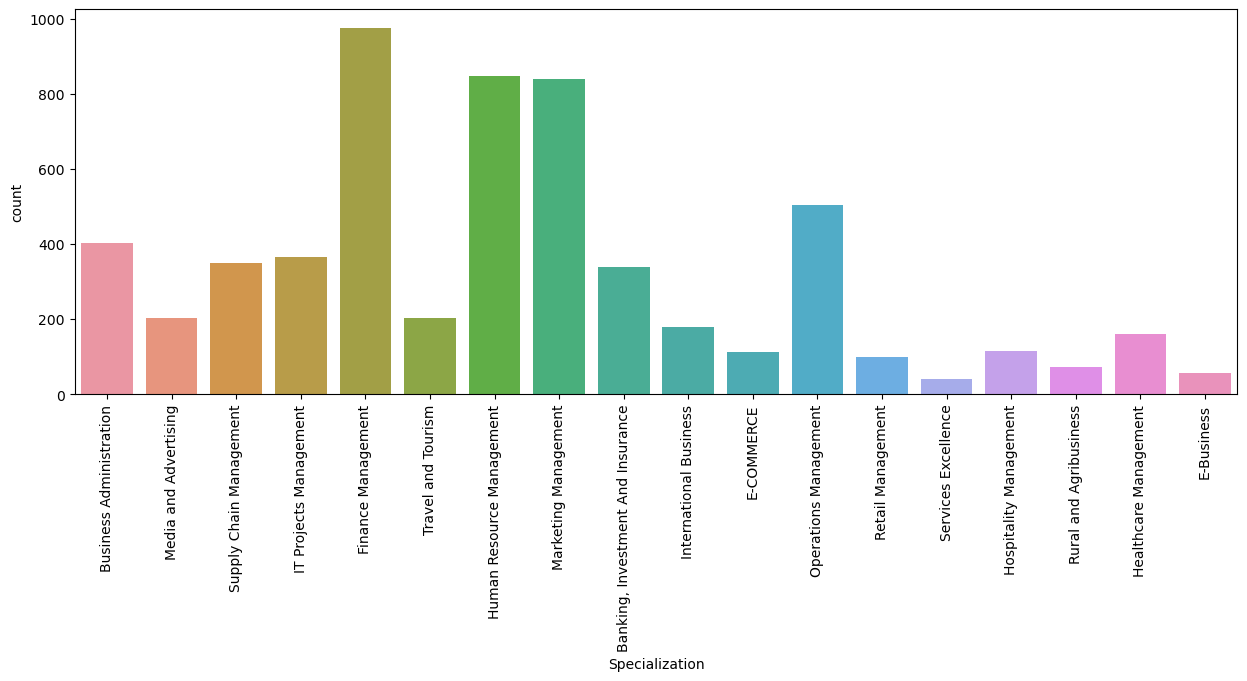

In [22]:
# Plotting count plot of 'Specialization' to see the data distribution:-

plt.figure(figsize=(15,5))
sns.countplot(x='Specialization', data= leads_df2)
plt.xticks(rotation=90)
plt.show()

In [23]:
# Imputing missing value with 'Other' :-

leads_df2['Specialization'].fillna('Other',inplace=True)

 Analyzing  columns with missing value less than 30%

In [24]:
 #Listing all the columns having missing values into 'remaining_missing':-

remaining_missing = leads_df2.columns[(100*(leads_df2.isnull().sum()/len(leads_df2)) < 30) & (100*(leads_df2.isnull().sum()/len(leads_df2)) >0) ]
print(remaining_missing)

Index(['Lead Source', 'TotalVisits', 'Page Views Per Visit', 'Last Activity', 'Country', 'What is your current occupation', 'What matters most to you in choosing a course'], dtype='object')


In [25]:
# Checking value counts of 'What is your current occupation' variable:-

leads_df2['What is your current occupation'].value_counts()

What is your current occupation
Unemployed              5600
Working Professional     706
Student                  210
Other                     16
Housewife                 10
Businessman                8
Name: count, dtype: int64

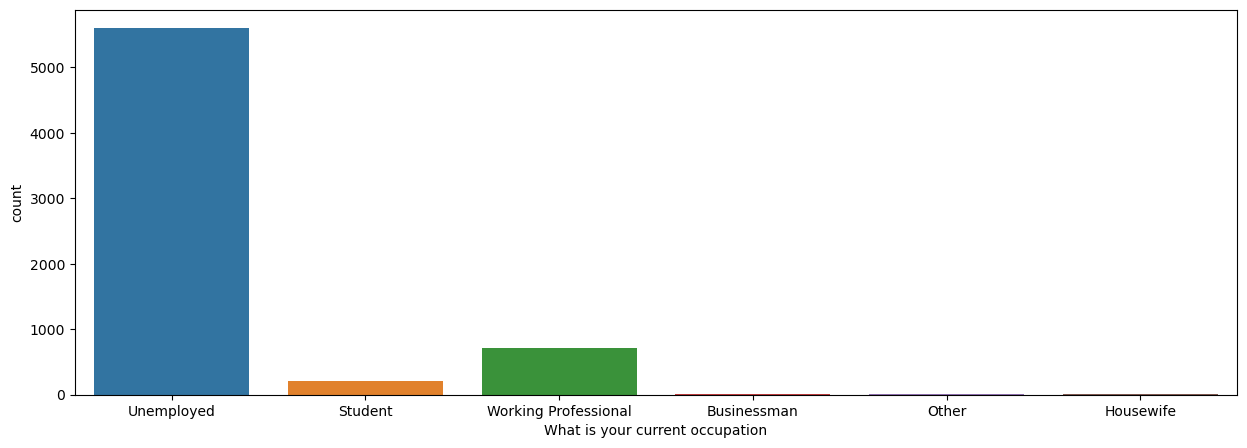

In [26]:
# Plotting count plot to check data counts in column 'What is your current occupation':-

plt.figure(figsize=(15,5))
sns.countplot(x='What is your current occupation', data= leads_df2)
plt.show()

Observation
We see that 'Unemployed' count is highest but we will impute missing values with 'Other' considering we do not know current occupation of lead.So we will create a separate category called 'Other'.

In [27]:
# Imputing missing value with 'Other' :-

leads_df2['What is your current occupation'].fillna('Other',inplace=True)

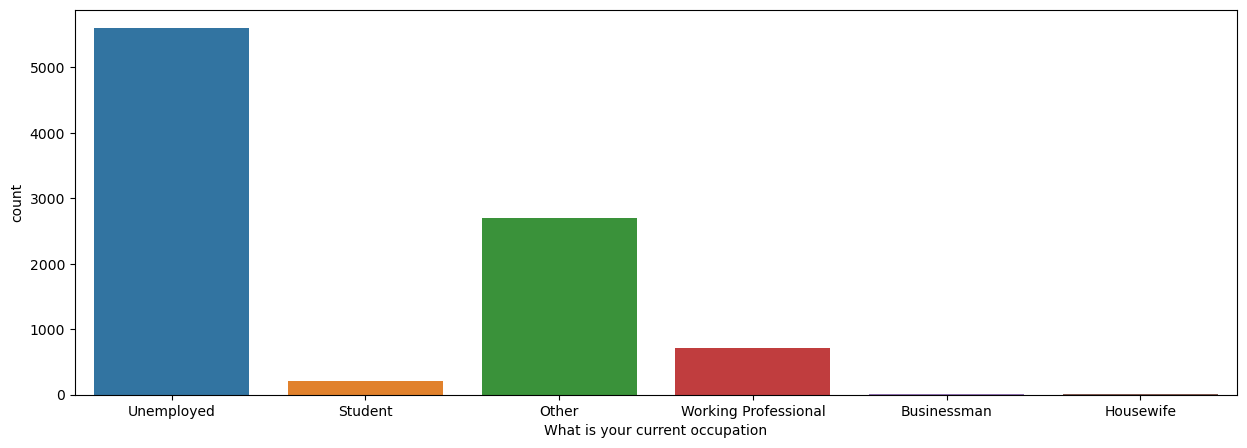

In [28]:
# Checking count of 'Other' after impuataion:-

plt.figure(figsize=(15,5))
sns.countplot(x='What is your current occupation', data= leads_df2)
plt.show()

In [29]:
# Checking value count of 'What matters most to you in choosing a course' variable:-

leads_df2['What matters most to you in choosing a course'].value_counts(normalize=True)*100

What matters most to you in choosing a course
Better Career Prospects      99.954065
Flexibility & Convenience     0.030623
Other                         0.015312
Name: proportion, dtype: float64

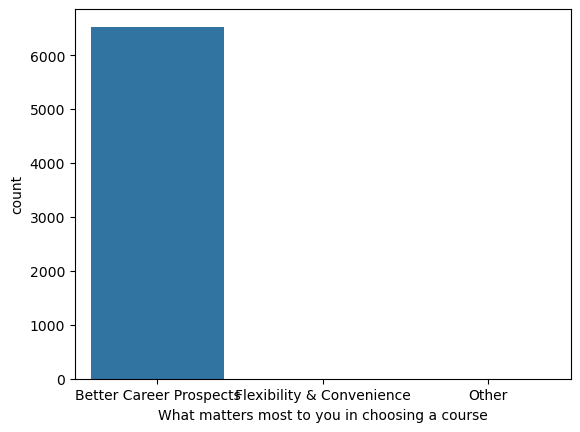

In [30]:
# Verifying counts by ploting count plot:-

sns.countplot(x="What matters most to you in choosing a course", data= leads_df2)
plt.show()

In [31]:
# Checking value counts of 'Country' column:-

leads_df2.Country.value_counts()

Country
India                   6492
United States             69
United Arab Emirates      53
Singapore                 24
Saudi Arabia              21
United Kingdom            15
Australia                 13
Qatar                     10
Hong Kong                  7
Bahrain                    7
Oman                       6
France                     6
unknown                    5
South Africa               4
Nigeria                    4
Germany                    4
Kuwait                     4
Canada                     4
Sweden                     3
China                      2
Asia/Pacific Region        2
Uganda                     2
Bangladesh                 2
Italy                      2
Belgium                    2
Netherlands                2
Ghana                      2
Philippines                2
Russia                     1
Switzerland                1
Vietnam                    1
Denmark                    1
Tanzania                   1
Liberia                    1
Malays

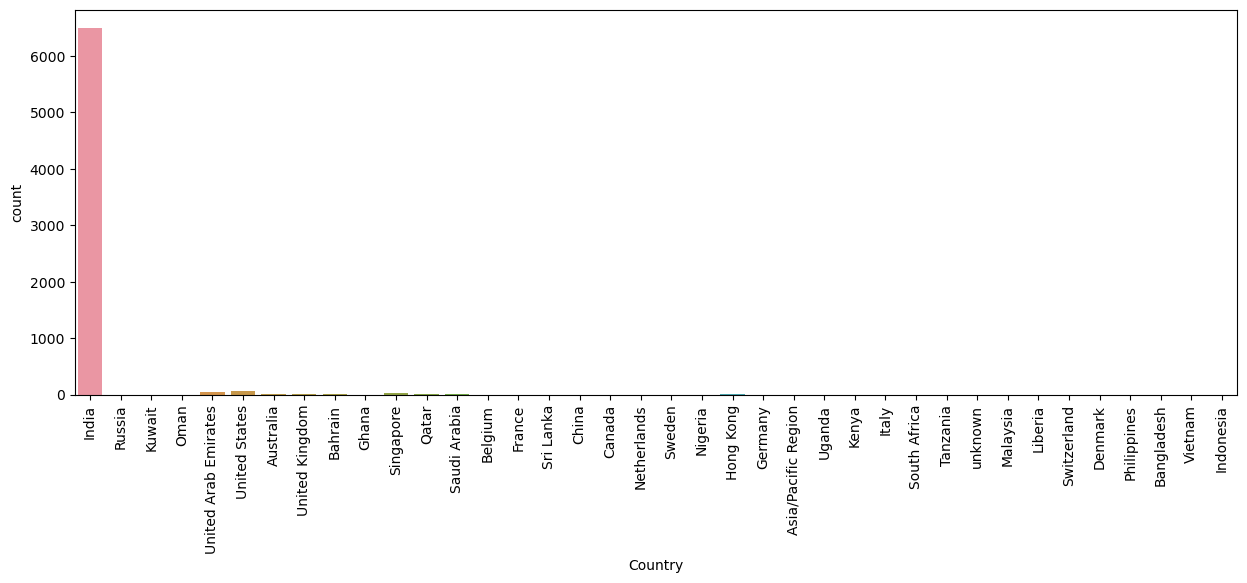

In [32]:
# Plotting count plot to visualize counts of data of 'Country' column:-

plt.figure(figsize=(15,5))
sns.countplot(x='Country', data= leads_df2)
plt.xticks(rotation=90)
plt.show()

Observation

From count plot we can see that 'India' count is highest so we can impute missing values with 'India'

In [33]:
# Replacing missing values with most frequent value 'India' in categorical column 'Country':-

leads_df2.Country.fillna('India',inplace=True)

In [34]:
leads_df2.Country.value_counts()

Country
India                   8953
United States             69
United Arab Emirates      53
Singapore                 24
Saudi Arabia              21
United Kingdom            15
Australia                 13
Qatar                     10
Hong Kong                  7
Bahrain                    7
Oman                       6
France                     6
unknown                    5
South Africa               4
Nigeria                    4
Germany                    4
Kuwait                     4
Canada                     4
Sweden                     3
China                      2
Asia/Pacific Region        2
Uganda                     2
Bangladesh                 2
Italy                      2
Belgium                    2
Netherlands                2
Ghana                      2
Philippines                2
Russia                     1
Switzerland                1
Vietnam                    1
Denmark                    1
Tanzania                   1
Liberia                    1
Malays

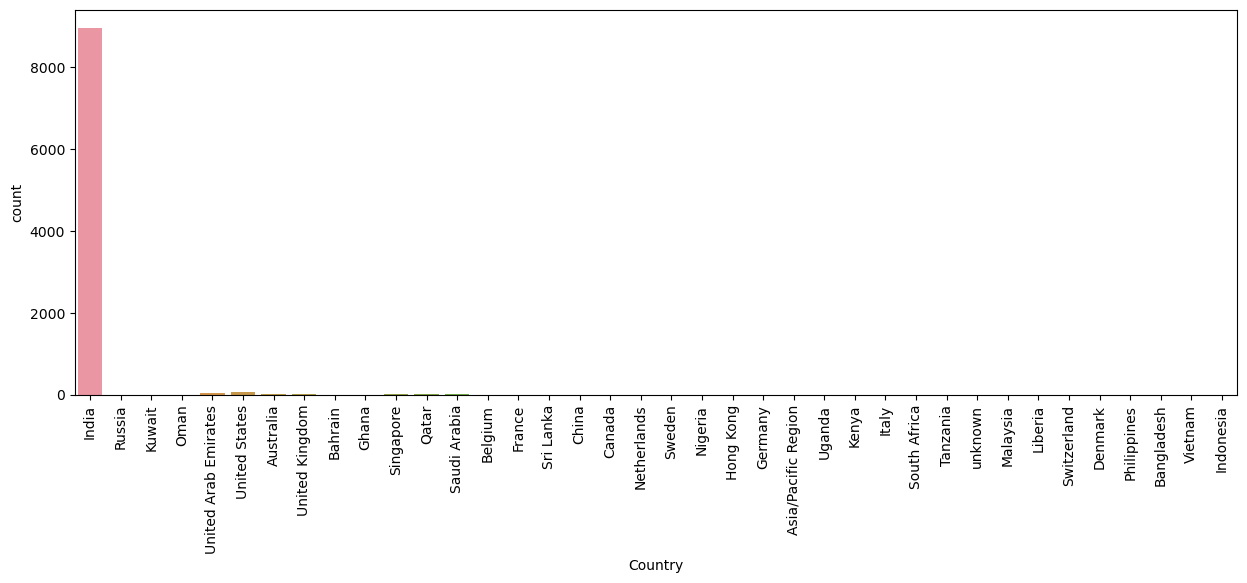

In [35]:
# To verify plotting count plot after imputation:-

plt.figure(figsize=(15,5))
sns.countplot(x='Country', data=leads_df2)
plt.xticks(rotation=90)
plt.show()

Observation

Before imputation in 'Country' column % of 'india' was ~70% but after imputing missing values with 'India' it's % became ~96% ,which will not contribute much in analysis so better to drop it cause data is skewed here.

In [36]:
# Dropping 'Country' column from dataframe:-

leads_df2.drop('Country',axis=1, inplace=True)

In [37]:
# Checking value counts of 'Lead Source':-

leads_df2['Lead Source'].value_counts()

Lead Source
Google               2868
Direct Traffic       2543
Olark Chat           1755
Organic Search       1154
Reference             534
Welingak Website      142
Referral Sites        125
Facebook               55
bing                    6
google                  5
Click2call              4
Press_Release           2
Social Media            2
Live Chat               2
youtubechannel          1
testone                 1
Pay per Click Ads       1
welearnblog_Home        1
WeLearn                 1
blog                    1
NC_EDM                  1
Name: count, dtype: int64

Observation

From above data we can see that there are two 'Google' and 'google' ,so better to replace 'google' with 'Google'.

'Google' is having highest number occurance so we can impute missing values with 'Google'.

In [38]:
# Replace 'google' with 'Google' :-

leads_df2['Lead Source']=leads_df2['Lead Source'].replace('google','Google')

In [39]:
# Verifying value counts again:-

leads_df2['Lead Source'].value_counts()

Lead Source
Google               2873
Direct Traffic       2543
Olark Chat           1755
Organic Search       1154
Reference             534
Welingak Website      142
Referral Sites        125
Facebook               55
bing                    6
Click2call              4
Social Media            2
Live Chat               2
Press_Release           2
Pay per Click Ads       1
blog                    1
WeLearn                 1
welearnblog_Home        1
youtubechannel          1
testone                 1
NC_EDM                  1
Name: count, dtype: int64

In [40]:
# Imputing missing values with 'Google':-

leads_df2['Lead Source'].fillna('Google',inplace=True)

In [41]:
# Checking value counts of 'Last Activity':-

leads_df2['Last Activity'].value_counts()

Last Activity
Email Opened                    3437
SMS Sent                        2745
Olark Chat Conversation          973
Page Visited on Website          640
Converted to Lead                428
Email Bounced                    326
Email Link Clicked               267
Form Submitted on Website        116
Unreachable                       93
Unsubscribed                      61
Had a Phone Conversation          30
Approached upfront                 9
View in browser link Clicked       6
Email Received                     2
Email Marked Spam                  2
Visited Booth in Tradeshow         1
Resubscribed to emails             1
Name: count, dtype: int64

Observation

As we do not know the last activity of leads which are missing values and most frequent value is 'Email Opened' so we can impute missing value with 'Email Opened'.

In [42]:
# Imputing missing values with 'Email Opened':-

leads_df2['Last Activity'] = leads_df2['Last Activity'].replace(np.nan, 'Email Opened')

In [43]:
# Imputing missing value with 'median' value for both 'TotalVisits' and 'Page Views Per Visit' columns:-

leads_df2['TotalVisits'].fillna(leads_df2['TotalVisits'].median(), inplace=True)

leads_df2['Page Views Per Visit'].fillna(leads_df2['Page Views Per Visit'].median(), inplace=True)

In [44]:
# Now checking shape of the dataframe:-

leads_df2.shape

(9240, 27)

In [45]:
# Checking missing values after treating missing values:-

round(100*(leads_df2.isnull().sum()/len(leads_df2)),2)

Prospect ID                                       0.00
Lead Number                                       0.00
Lead Origin                                       0.00
Lead Source                                       0.00
Do Not Email                                      0.00
Do Not Call                                       0.00
Converted                                         0.00
TotalVisits                                       0.00
Total Time Spent on Website                       0.00
Page Views Per Visit                              0.00
Last Activity                                     0.00
Specialization                                    0.00
What is your current occupation                   0.00
What matters most to you in choosing a course    29.32
Search                                            0.00
Magazine                                          0.00
Newspaper Article                                 0.00
X Education Forums                                0.00
Newspaper 

Observation

We can see that there is no missing values now,so we can proceed with next task

Checking 'Prospect ID' and 'Lead Number' columns

In [46]:
# Checking duplicate values in 'Prospect ID':-

leads_df2.duplicated(subset = 'Prospect ID').sum()

0

In [47]:
# Checking duplicate values in 'Lead Number':-

leads_df2.duplicated(subset = 'Lead Number').sum()

0

Observation

'Prospect ID' and 'Lead Number' both do not have duplicate values means these columns identify each data uniquely so working as unique Id and will not make any significant impact on our model.So we can drop it.

In [48]:
# Dropping 'Prospect ID' and 'Lead Number' variables:-

leads_df2.drop(['Prospect ID','Lead Number'], axis=1, inplace=True)

Value_counts of variables to check data balancing

In [49]:
# Checking the value_counts of remaining variables for better data understanding :-

cols=list(leads_df2.iloc[:,:])  # Creating list 'cols' of variables


for i in cols:
    print(i,'=====')
    print(leads_df2[i].value_counts(), '\n')

Lead Origin =====
Lead Origin
Landing Page Submission    4886
API                        3580
Lead Add Form               718
Lead Import                  55
Quick Add Form                1
Name: count, dtype: int64 

Lead Source =====
Lead Source
Google               2909
Direct Traffic       2543
Olark Chat           1755
Organic Search       1154
Reference             534
Welingak Website      142
Referral Sites        125
Facebook               55
bing                    6
Click2call              4
Social Media            2
Live Chat               2
Press_Release           2
Pay per Click Ads       1
blog                    1
WeLearn                 1
welearnblog_Home        1
youtubechannel          1
testone                 1
NC_EDM                  1
Name: count, dtype: int64 

Do Not Email =====
Do Not Email
No     8506
Yes     734
Name: count, dtype: int64 

Do Not Call =====
Do Not Call
No     9238
Yes       2
Name: count, dtype: int64 

Converted =====
Converted
0    5679
1 

Observation

From the above value_counts data we can see that columns 'Do Not Call','Search','Magazine','Newspaper Article','X Education Forums','Newspaper,'Digital Advertisement','Through Recommendations','Receive More Updates About Our Courses','Update me on Supply Chain Content','
Get updates on DM Content','I agree to pay the amount through cheque' are having highly imbalance data or skewed data and these variables will not contribute significatly to analysis ,so better to drop these columns.

In [50]:
# Dropping variables which are having imbalanced data:-

leads_df2.drop(['Do Not Call','What matters most to you in choosing a course','Search','Magazine','Newspaper Article','X Education Forums','Newspaper',
          'Digital Advertisement','Through Recommendations','Receive More Updates About Our Courses','Update me on Supply Chain Content','Get updates on DM Content','I agree to pay the amount through cheque'],axis=1,inplace=True)

In [51]:
# Dropping column 'last Notable Activity':-

leads_df2.drop('Last Notable Activity',axis=1,inplace=True)

In [52]:
# Checking shape of the dataframe after dropping variables:-

leads_df2.shape

(9240, 11)

In [53]:
# Displaying head of 'lead_df1' dataframe :-

leads_df2.head()

,Lead Origin,Lead Source,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,What is your current occupation,A free copy of Mastering The Interview
0,API,Olark Chat,No,0,0.0,0,0.0,Page Visited on Website,Other,Unemployed,No
1,API,Organic Search,No,0,5.0,674,2.5,Email Opened,Other,Unemployed,No
2,Landing Page Submission,Direct Traffic,No,1,2.0,1532,2.0,Email Opened,Business Administration,Student,Yes
3,Landing Page Submission,Direct Traffic,No,0,1.0,305,1.0,Unreachable,Media and Advertising,Unemployed,No
4,Landing Page Submission,Google,No,1,2.0,1428,1.0,Converted to Lead,Other,Unemployed,No


Step 3: Exploratory Data Analysis(EDA)
    
Univariate Analysis
As per problem statement 'Converted' is our target variable.

The target variable. Indicates whether a lead has been successfully converted or not.

0: Not converted into lead.

1: Lead has been successfully Converted.

*Calculating conversion rate

In [54]:
# Calculating conversion rate:-

Converted = (sum(leads_df2['Converted'])/len(leads_df2['Converted'].index))*100
Converted

38.53896103896104

Checking Distribution of 'TARGET' Variable

In [55]:
#Checking value count of target variable 'Converted':-

leads_df2.Converted.value_counts()

Converted
0    5679
1    3561
Name: count, dtype: int64

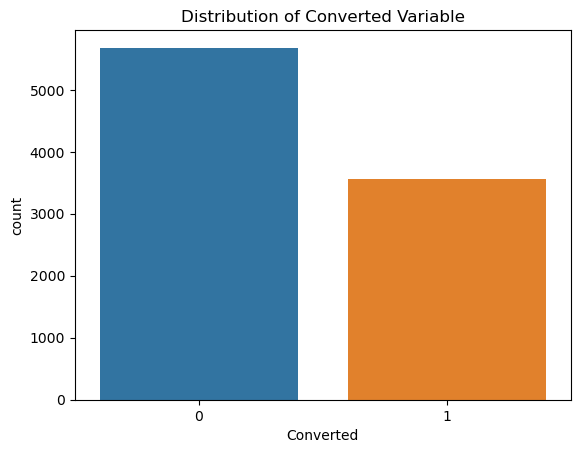

In [56]:
#Plotting count plot to get clear view of data distribution of 'Converted' column:-

sns.countplot(x='Converted', data=leads_df2)
plt.title("Distribution of Converted Variable")
plt.show()

In [57]:
#Checking ratio of imbalance:-

(leads_df2.Converted==1).sum()/(leads_df2.Converted==0).sum()

0.6270470153195985

Observation

From value count and count plot we can see that data is properly balanced with respect to ratio.

In [58]:
# Again checking data types of remaining columns:-

leads_df2.dtypes

Lead Origin                                object
Lead Source                                object
Do Not Email                               object
Converted                                   int64
TotalVisits                               float64
Total Time Spent on Website                 int64
Page Views Per Visit                      float64
Last Activity                              object
Specialization                             object
What is your current occupation            object
A free copy of Mastering The Interview     object
dtype: object

Analyzing Categorical Variables

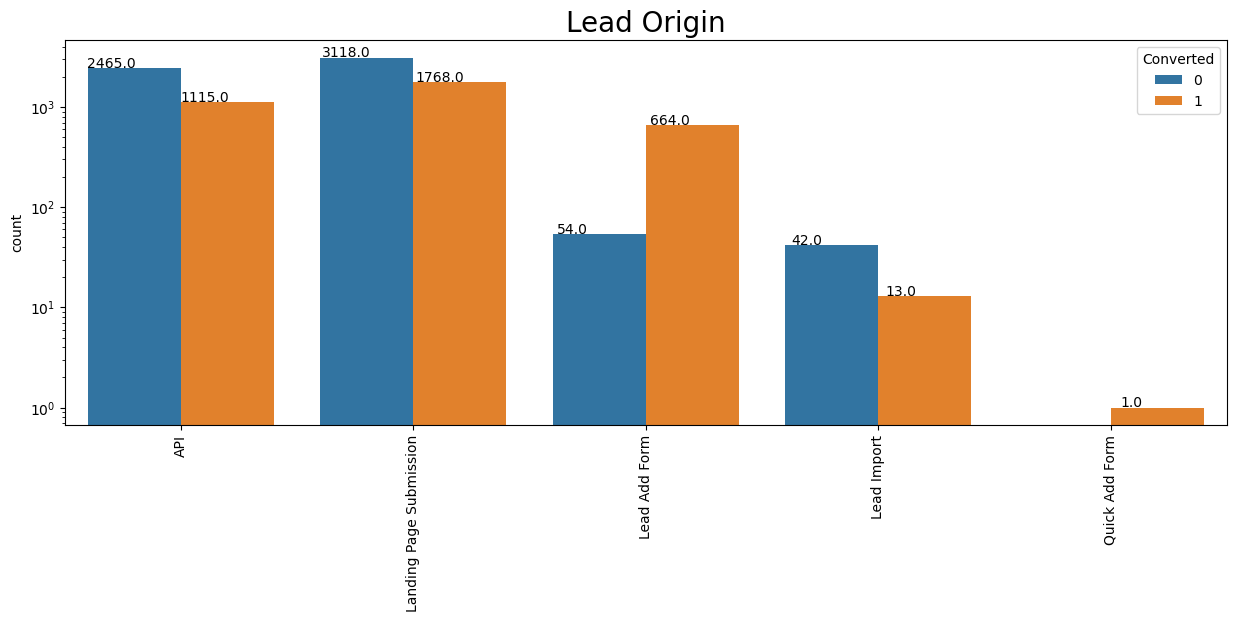

In [59]:
# Plotting count plot of 'Lead Origin' for both 'Converted' 0 and 1 :-

plt.figure(figsize = (15,5))

ax=sns.countplot(x = "Lead Origin", hue = "Converted", data = leads_df2)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.01 , p.get_height() * 1.01))
ax.set(xlabel=None)

plt.xticks(rotation = 90)
plt.title('Lead Origin',fontsize=20)
ax.set_yscale('log')

plt.show()

Observation

From above plot we can observe and calculate that :

Conversion rate for 'API' is ~ 31% and for 'Landing Page Submission' is ~36%.

For 'Lead Add Form' number of conversion is more than unsuccessful conversion.

Count of 'Lead Import' is lesser.

Recommendation

To improve overall lead conversion rate, we need to focus more on improving lead conversion of API and Landing Page Submission origin and generate more leads from Lead Add Form

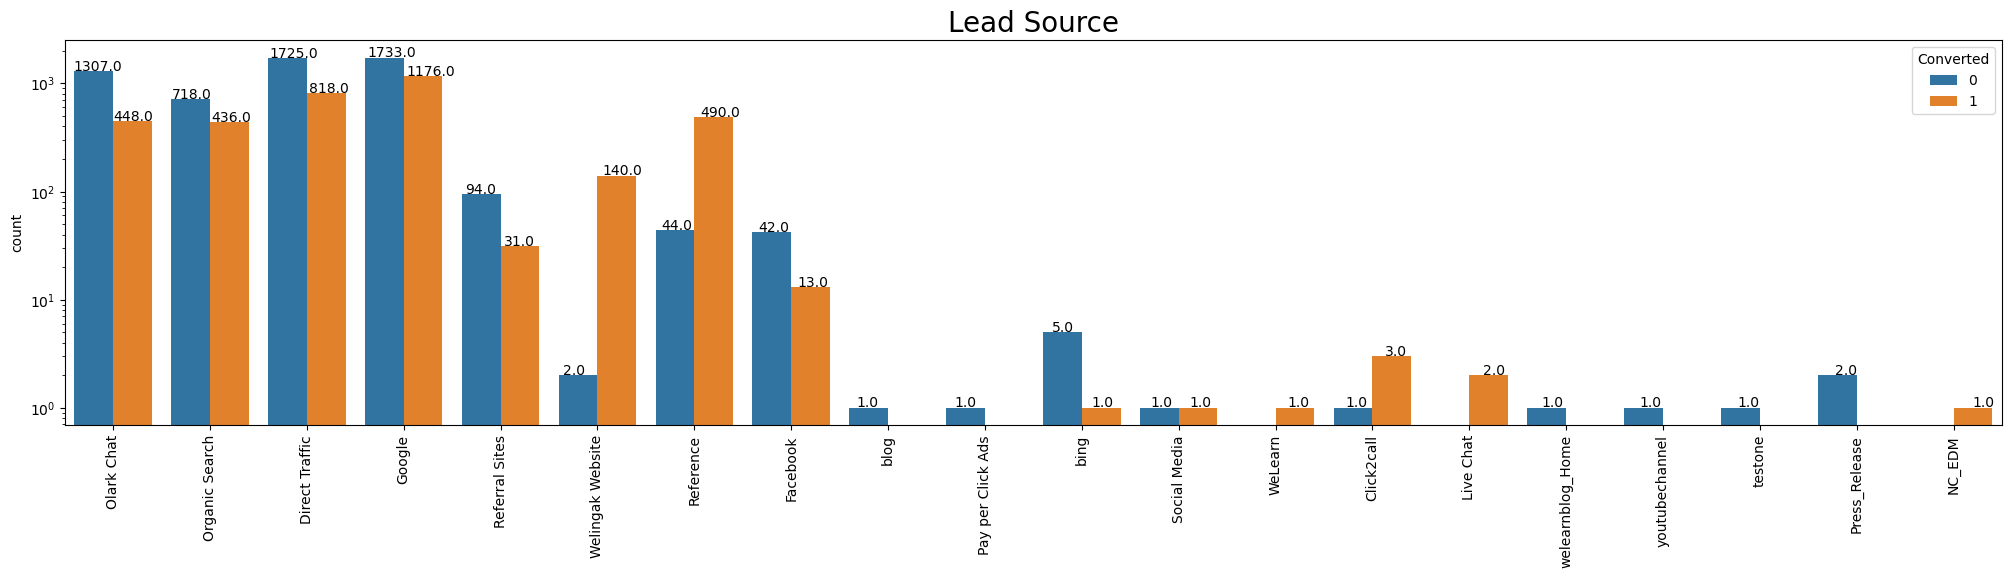

In [60]:
# Plotting count plot of 'Lead Source' based on 'Converted' value 0 and 1 :-

plt.figure(figsize = (25,5))

ax=sns.countplot(x = "Lead Source", hue = "Converted", data = leads_df2)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.01 , p.get_height() * 1.01))
ax.set(xlabel=None)

plt.xticks(rotation = 90)
plt.title('Lead Source',fontsize=20)

ax.set_yscale('log')# Setting logrithmic scale

plt.show()

Clubbing lower frequency values together under a common label 'Others'

In [61]:
# Combining all low frequency values together:-

leads_df2['Lead Source'] = leads_df2['Lead Source'].replace(['blog','Pay per Click Ads','bing','Social Media','WeLearn','Click2call', 'Live Chat','welearnblog_Home', 'youtubechannel','testone',
                                                           'Press_Release','NC_EDM'], 'Others')

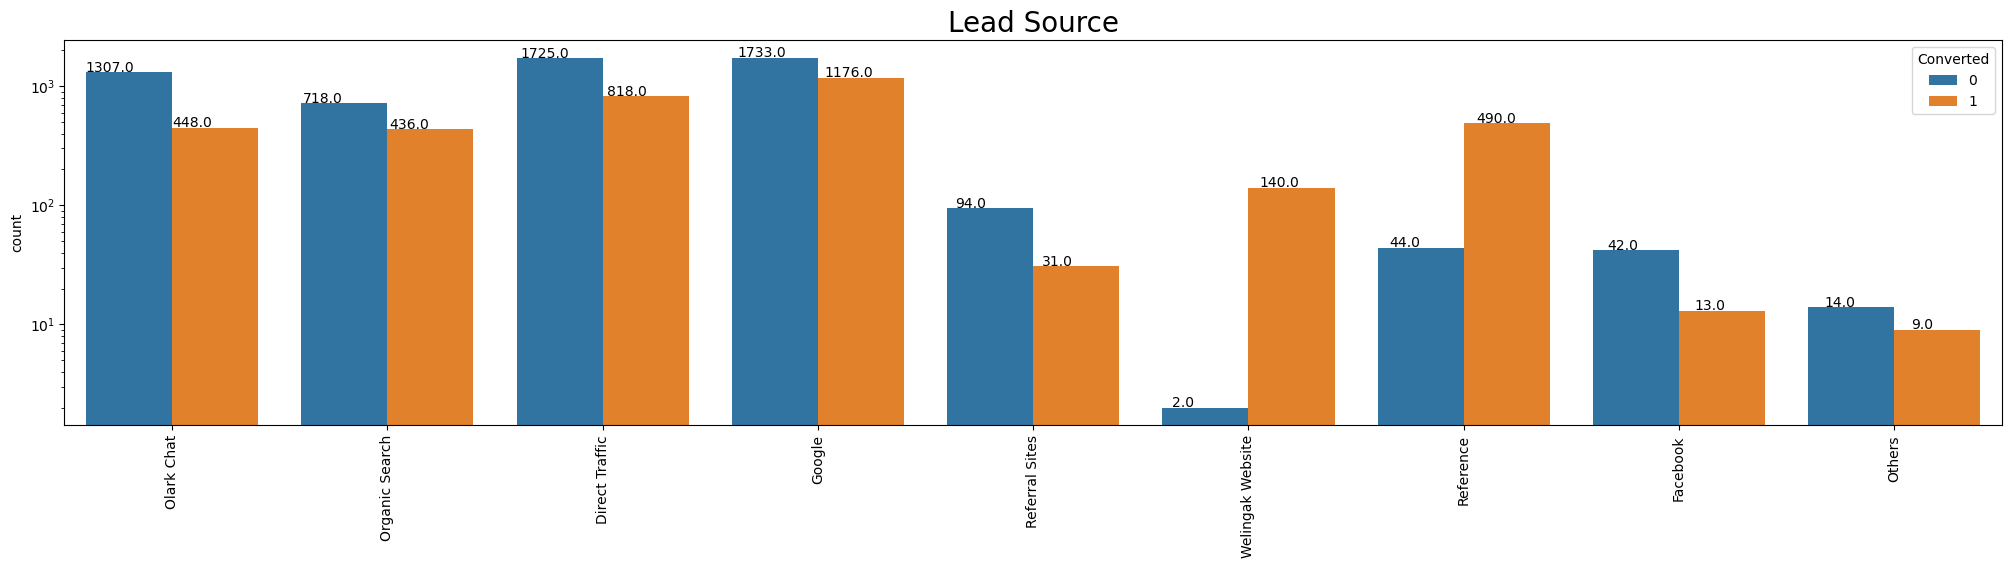

In [62]:
# Again plotting count plot of 'Lead Source' based on 'Converted' value 0 and 1 :-

plt.figure(figsize = (25,5))

ax=sns.countplot(x = "Lead Source", hue = "Converted", data = leads_df2)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.01 , p.get_height() * 1.01))
ax.set(xlabel=None)

plt.xticks(rotation = 90)
plt.title('Lead Source',fontsize=20)

ax.set_yscale('log')

plt.show()

Observation

From above plot we can observe:

Google and Direct traffic generates maximum number of leads.

Conversion rate of 'Reference' and 'Welingak Website' leads is high.

Recommendation

To improve overall lead conversion rate, focus should be on improving lead converion of olark chat, organic search, direct traffic, and google leads and generate more leads from reference and welingak website.

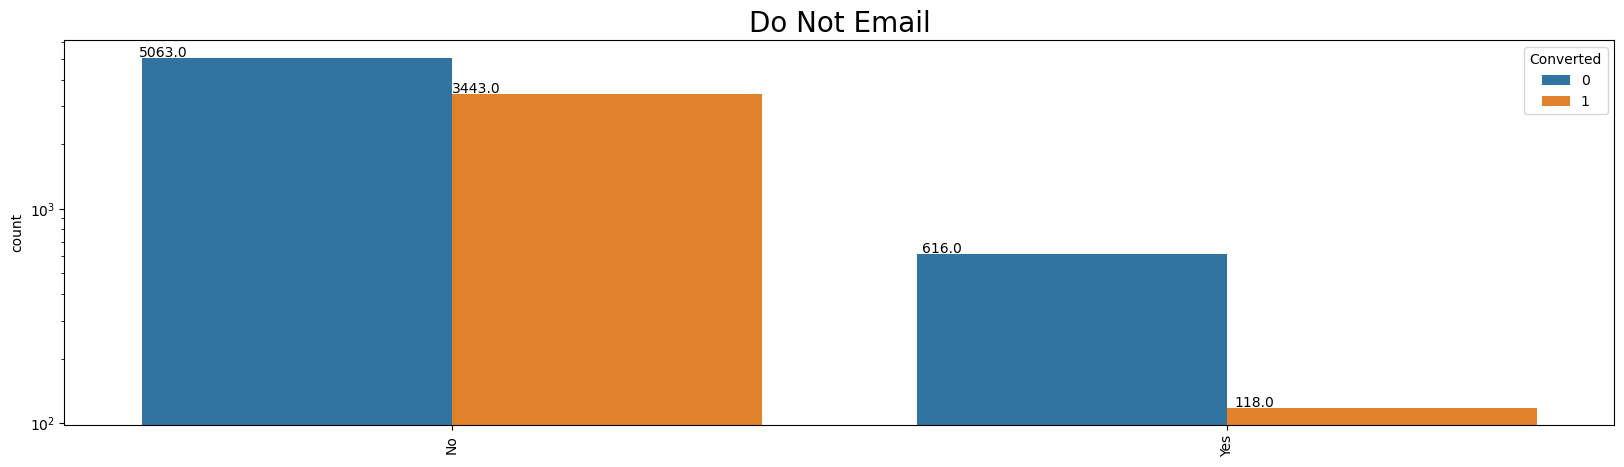

In [63]:
# Plotting count plot of 'Lead Source' based on 'Converted' value 0 and 1 :-

plt.figure(figsize = (20,5))

ax=sns.countplot(x = "Do Not Email", hue = "Converted", data = leads_df2)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.01 , p.get_height() * 1.01))
ax.set(xlabel=None)

plt.xticks(rotation = 90)
plt.title('Do Not Email',fontsize=20)

ax.set_yscale('log')# Setting logrithmic scale

plt.show()

Observation

People who opted for mail option are becoming more leads.

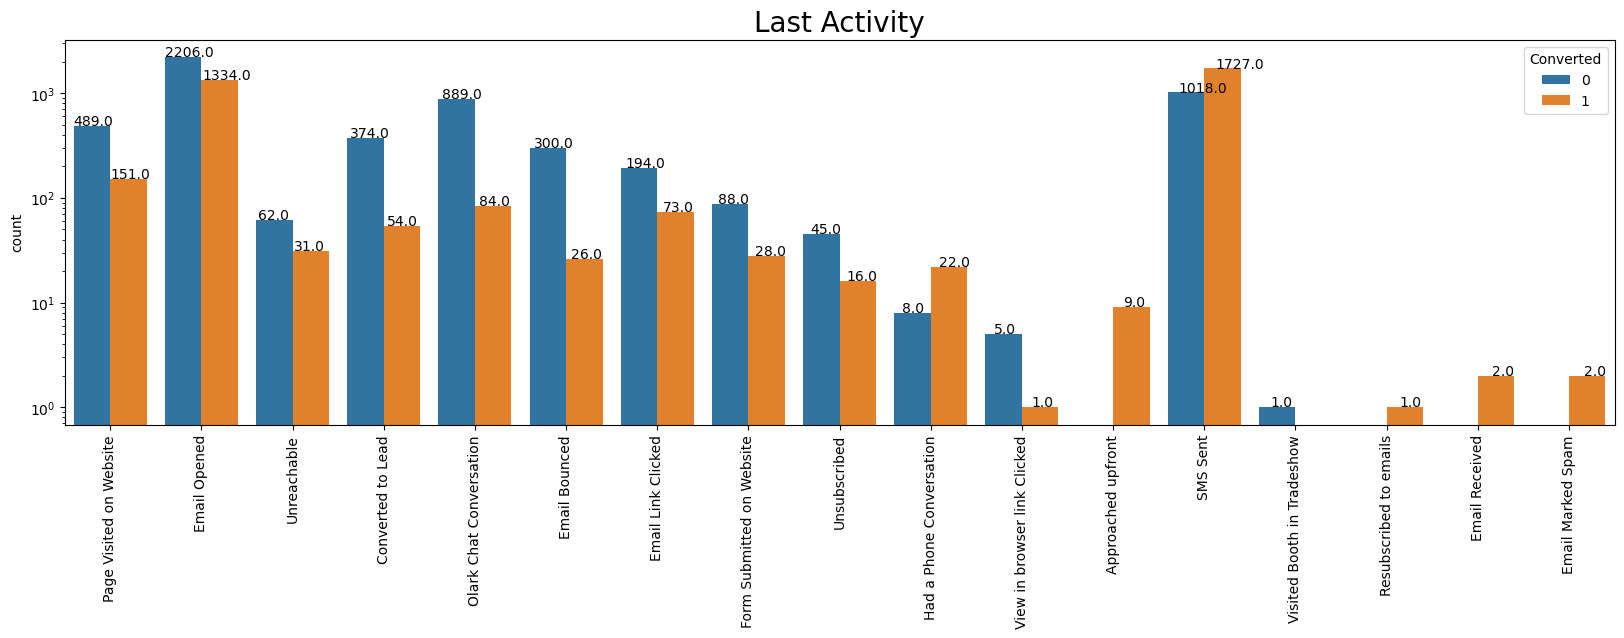

In [64]:
# Plotting count plot of 'Lead Source' based on 'Converted' value 0 and 1 :-

plt.figure(figsize = (20,5))

ax=sns.countplot(x = "Last Activity", hue = "Converted", data = leads_df2)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.01 , p.get_height() * 1.01))
ax.set(xlabel=None)

plt.xticks(rotation = 90)
plt.title('Last Activity',fontsize=20)

ax.set_yscale('log')# Setting logrithmic scale

plt.show()

In [65]:
# Combining all low frequency values together under label 'Others':-

leads_df2['Last Activity'] = leads_df2['Last Activity'].replace(['Had a Phone Conversation','View in browser link Clicked','Visited Booth in Tradeshow',
      'Approached upfront','Resubscribed to emails','Email Received','Email Marked Spam'],'Others')

Text(0.5, 1.0, 'Last Activity of Lead')

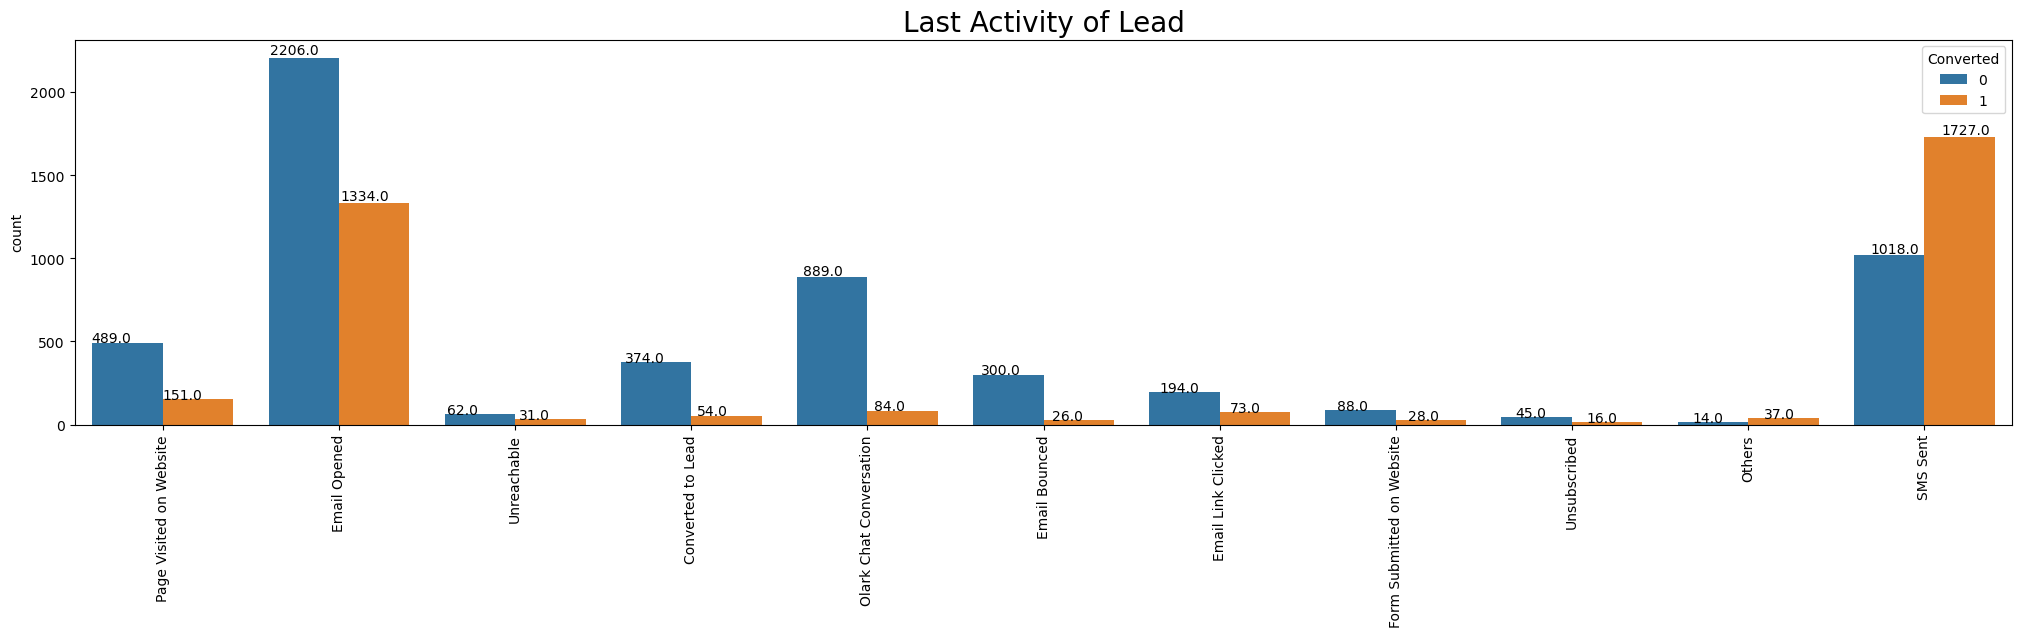

In [66]:
# Again plotting count plot of 'Last Activity' based on 'Converted' value 0 and 1 :-

plt.figure(figsize = (25,5))

ax=sns.countplot(x = "Last Activity", hue = "Converted", data = leads_df2)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.01 , p.get_height() * 1.01))
ax.set(xlabel=None)

plt.xticks(rotation = 90)
plt.title('Last Activity of Lead',fontsize=20)

Observation

From above plot we can observe :

Conversion rate for last activity of 'SMS Sent'is ~63%.
Highest last activity of leads is 'Email Opened' .

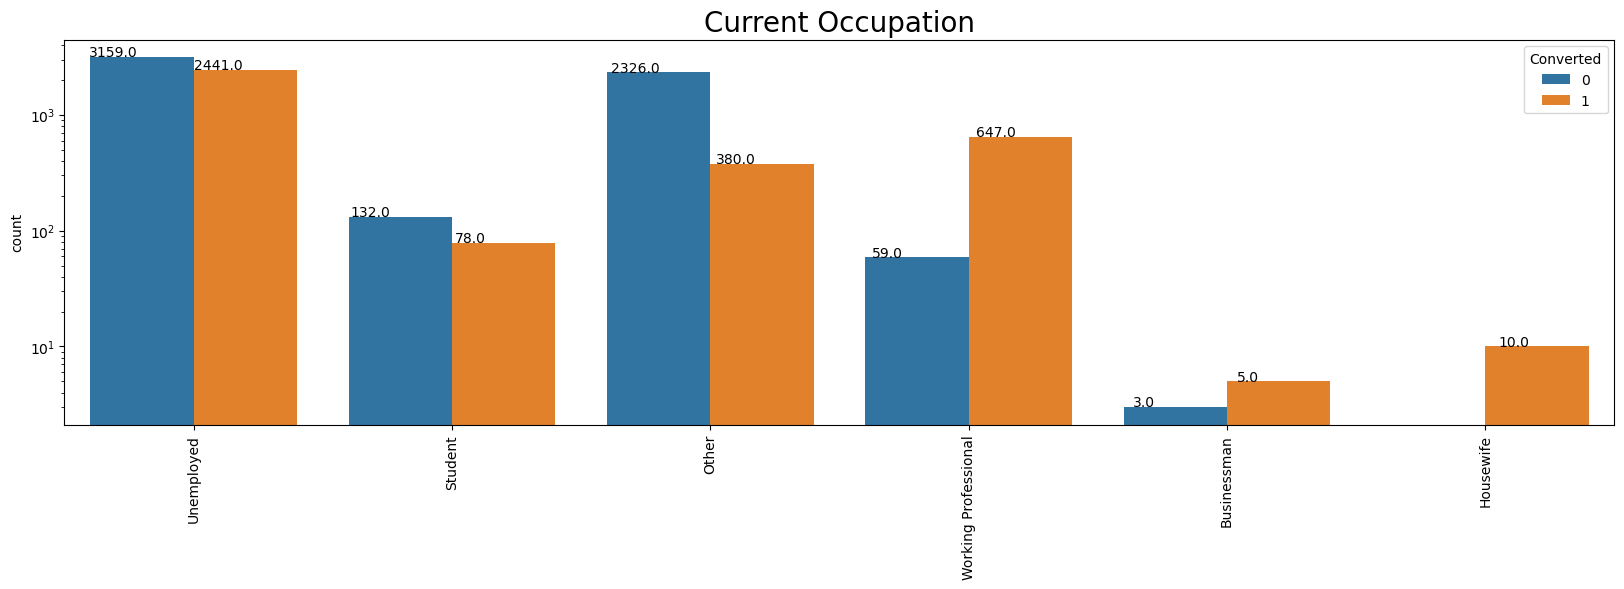

In [67]:
# Plotting count plot of 'What is your current occupation' based on 'Converted' value 0 and 1 :-

plt.figure(figsize = (20,5))

ax=sns.countplot(x = "What is your current occupation", hue = "Converted", data = leads_df2)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.01 , p.get_height() * 1.01))
ax.set(xlabel=None)

plt.xticks(rotation = 90)
plt.title('Current Occupation',fontsize=20)

ax.set_yscale('log')# Setting logrithmic scale

plt.show()

Observation

'Unemployed' leads are generationg more number of leads and having ~45% conversion rate.
Conversion rate is higher for 'Working Professionals' .


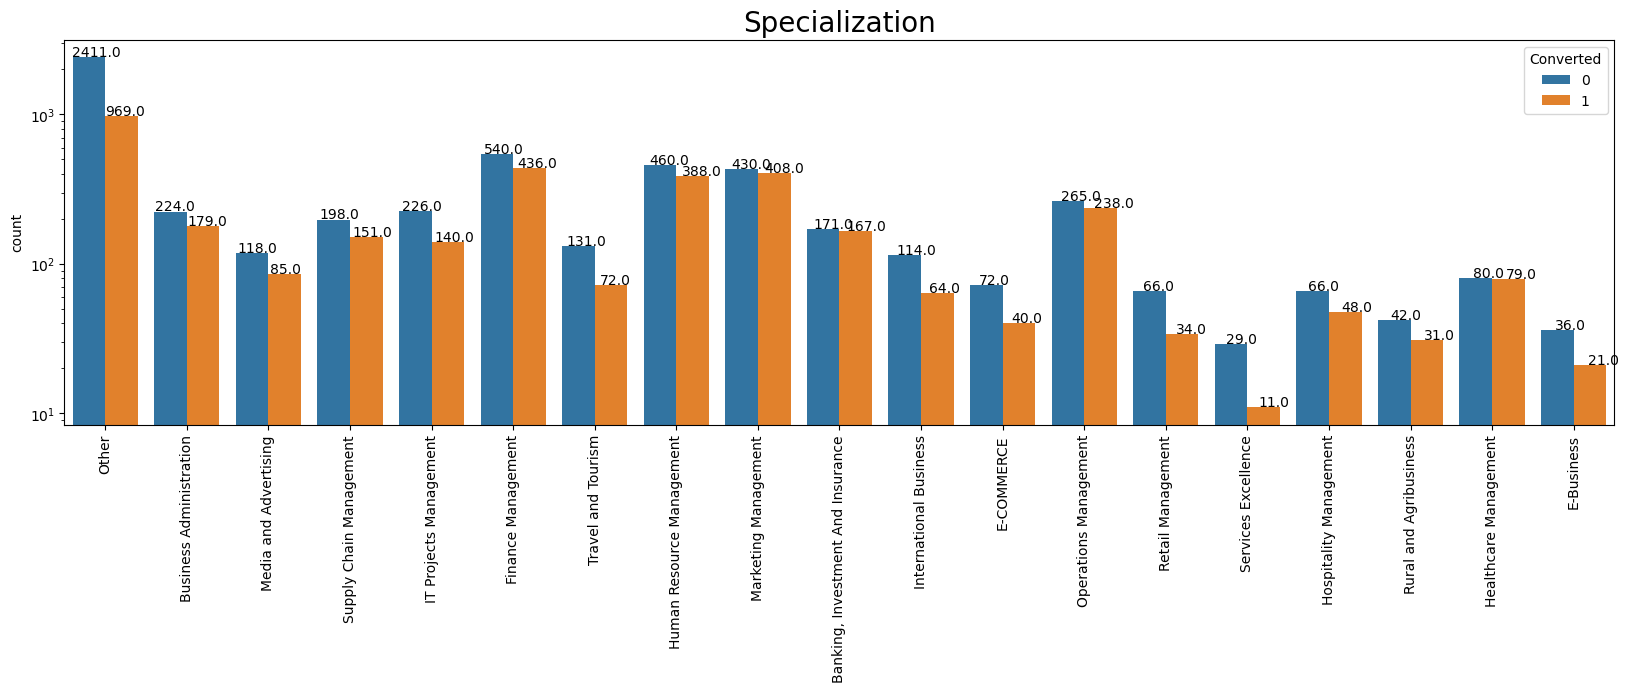

In [68]:
# Plotting count plot of 'Specialization' based on 'Converted' value 0 and 1 :-

plt.figure(figsize = (20,5))

ax=sns.countplot(x = "Specialization", hue = "Converted", data = leads_df2)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.01 , p.get_height() * 1.01))
ax.set(xlabel=None)

plt.xticks(rotation = 90)
plt.title('Specialization',fontsize=20)

ax.set_yscale('log')# Setting logrithmic scale

plt.show()

Observation

We can observe from above count plot of 'Specialization' that 'Management' specialization altogether having more number of leads generating.And Other category is also generating more number of leads.

--Analyzing Numerical Variables

Outlier Analysis and treatment

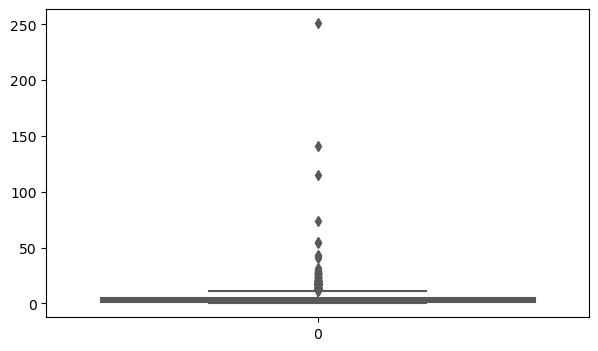

In [69]:
# Plotting box plots to visualize data distribution of 'TotalVisits':-

plt.figure(figsize = (7,4))
sns.boxplot(leads_df2['TotalVisits'],orient='v',palette='Set2')

plt.show()

Observation

We can see from above box plot that only upper range outliers are present in data, so need to treat outliers.

In [70]:
# Treating outliers by capping upper range to 0.99:-

Q3 = leads_df2.TotalVisits.quantile(0.99)

leads_df2 = leads_df2[(leads_df2.TotalVisits <= Q3)]

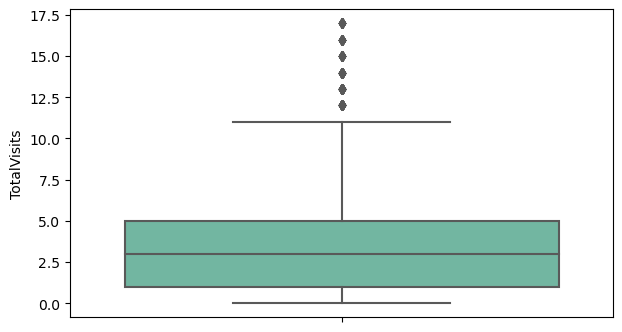

In [71]:
# Verifying outliers after removing it :-

plt.figure(figsize = (7,4))
sns.boxplot(y=leads_df2['TotalVisits'],palette='Set2')
plt.show()

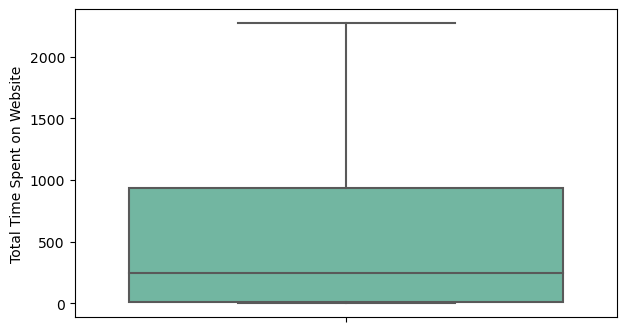

In [72]:
# Plotting box plots to visualize data distribution of 'Total Time Spent on Website':-

plt.figure(figsize=(7,4))
sns.boxplot(y=leads_df2['Total Time Spent on Website'],orient='v',palette='Set2')
plt.show()

Observation

From above box plot we can see that there is no outlier in data,so no trreatment required for it.

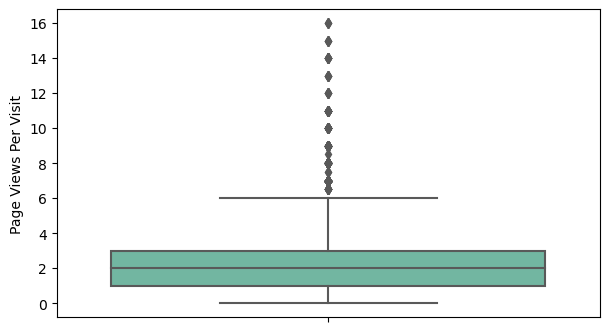

In [73]:
# Plotting box plots to visualize data distribution of 'Page Views Per Visit':-

plt.figure(figsize=(7,4))
sns.boxplot(y=leads_df2['Page Views Per Visit'],orient='v',palette='Set2')
plt.show()

Observation


We can see from above box plot that only upper range outliers are present in data, so need to lower range treat outliers.


In [74]:
# Treating upper range outliers by capping upper range to 0.99:-

Q3 = leads_df2['Page Views Per Visit'].quantile(0.99)

leads_df2 = leads_df2[(leads_df2['Page Views Per Visit'] <= Q3)]

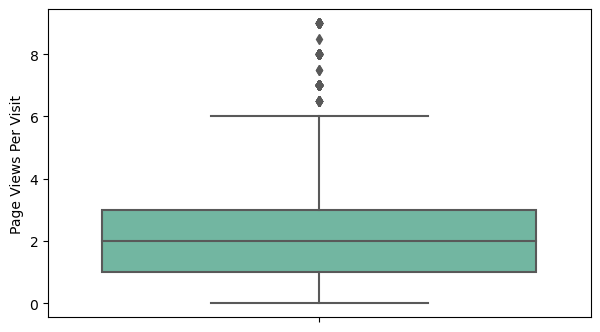

In [75]:
# Verifying outliers after removing it :-

plt.figure(figsize = (7,4))
sns.boxplot(y=leads_df2['Page Views Per Visit'],palette='Set2')
plt.show()

Bivariate Analysis

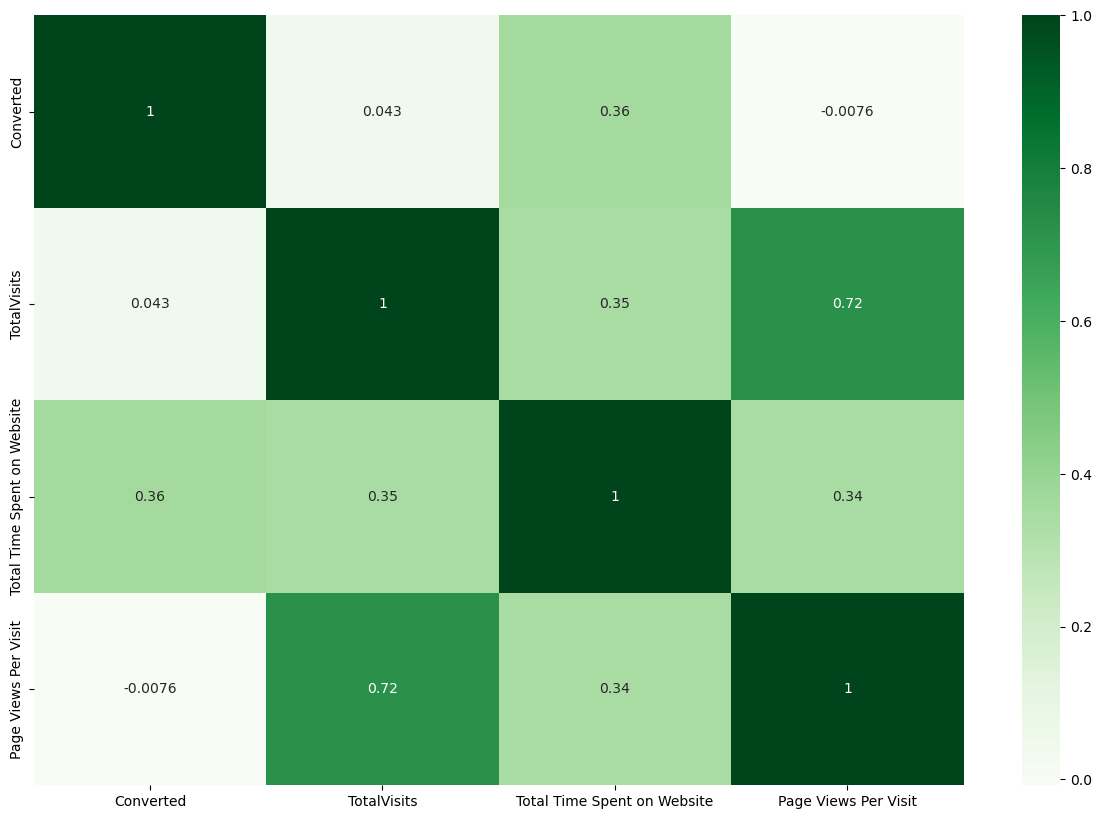

In [76]:
# Heatmap to understand the attributes correlation:-

plt.figure(figsize = (15,10))        
ax = sns.heatmap(leads_df2.corr(numeric_only=True),annot=True, cmap='Greens')

Observation

'TotalVisits' and 'Page Views per Visit' are highly correlated with correlation of .72

'Total Time Spent on Website' has correlation of 0.36 with target variable 'Converted'.

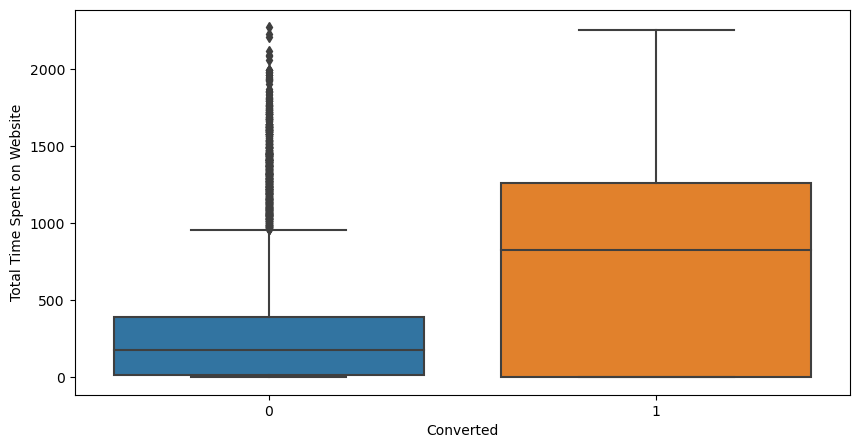

In [77]:
# Plotting box plot of "Total Time Spent on Website" vs Converted variable to check data distribution:-

plt.figure(figsize=(10,5))
sns.boxplot(x='Converted', y='Total Time Spent on Website',data=leads_df2)
plt.show()

Observation

Leads spending more time on website are more likely to opt for curses or converted.

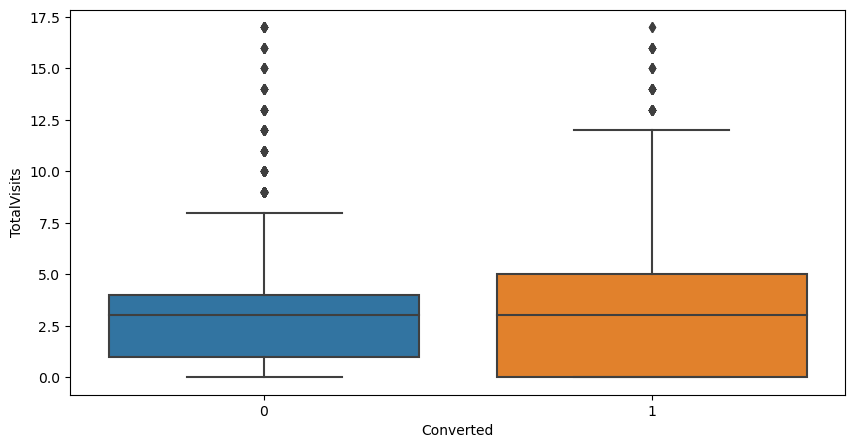

In [78]:
# Plotting box of "Total Visits" vs Converted variable to check data distribution:-

plt.figure(figsize=(10,5))
sns.boxplot(y = 'TotalVisits', x = 'Converted', data = leads_df2)
plt.show()

Observation

From above plot we can see that median for converted and non-converted is approx same.

# Step 4: Data Preparation
    
Converting some binary variables (Yes/No) to 0/1

In [79]:
# Variable to map:-

var =  ['Do Not Email','A free copy of Mastering The Interview']

# Defining the map function
def binary_map(x):
    return x.map({'Yes': 1, "No": 0})

# Applying the function to the variable:-

leads_df2[var] = leads_df2[var].apply(binary_map)

In [80]:
# Checking head of dataframe again:-

leads_df2.head()

,Lead Origin,Lead Source,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,What is your current occupation,A free copy of Mastering The Interview
0,API,Olark Chat,0,0,0.0,0,0.0,Page Visited on Website,Other,Unemployed,0
1,API,Organic Search,0,0,5.0,674,2.5,Email Opened,Other,Unemployed,0
2,Landing Page Submission,Direct Traffic,0,1,2.0,1532,2.0,Email Opened,Business Administration,Student,1
3,Landing Page Submission,Direct Traffic,0,0,1.0,305,1.0,Unreachable,Media and Advertising,Unemployed,0
4,Landing Page Submission,Google,0,1,2.0,1428,1.0,Converted to Lead,Other,Unemployed,0


Creating Dummy Variable

For categorical variables with multiple levels, create dummy features (one-hot encoded)

In [81]:
# Creating list 'cat_col' of categorical columns :-

cat_col= leads_df2.select_dtypes(include=['object']).columns
cat_col

Index(['Lead Origin', 'Lead Source', 'Last Activity', 'Specialization', 'What is your current occupation'], dtype='object')

In [82]:
# Creating dummy variable for some of the categorical variables and dropping the first one using 'drop_first=True':-

dummy = pd.get_dummies(leads_df2[['Lead Origin', 'Lead Source', 'Last Activity','What is your current occupation',
                             'Specialization']], dtype=int,drop_first=True)

dummy.head()

,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Facebook,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_Others,Lead Source_Reference,Lead Source_Referral Sites,Lead Source_Welingak Website,Last Activity_Email Bounced,Last Activity_Email Link Clicked,Last Activity_Email Opened,Last Activity_Form Submitted on Website,Last Activity_Olark Chat Conversation,Last Activity_Others,Last Activity_Page Visited on Website,Last Activity_SMS Sent,Last Activity_Unreachable,Last Activity_Unsubscribed,What is your current occupation_Housewife,What is your current occupation_Other,What is your current occupation_Student,What is your current occupation_Unemployed,What is your current occupation_Working Professional,Specialization_Business Administration,Specialization_E-Business,Specialization_E-COMMERCE,Specialization_Finance Management,Specialization_Healthcare Management,Specialization_Hospitality Management,Specialization_Human Resource Management,Specialization_IT Projects Management,Specialization_International Business,Specialization_Marketing Management,Specialization_Media and Advertising,Specialization_Operations Management,Specialization_Other,Specialization_Retail Management,Specialization_Rural and Agribusiness,Specialization_Services Excellence,Specialization_Supply Chain Management,Specialization_Travel and Tourism
0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [83]:
# Adding dummy variables dataset 'dummy' to original dataset 'lead_df1':-

leads_df2= pd.concat([dummy,leads_df2],axis = 1)

In [84]:
#Checking head of dataframe 'lead_df1':-

leads_df2.head()

,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Facebook,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_Others,Lead Source_Reference,Lead Source_Referral Sites,Lead Source_Welingak Website,Last Activity_Email Bounced,Last Activity_Email Link Clicked,Last Activity_Email Opened,Last Activity_Form Submitted on Website,Last Activity_Olark Chat Conversation,Last Activity_Others,Last Activity_Page Visited on Website,Last Activity_SMS Sent,Last Activity_Unreachable,Last Activity_Unsubscribed,What is your current occupation_Housewife,What is your current occupation_Other,What is your current occupation_Student,What is your current occupation_Unemployed,What is your current occupation_Working Professional,Specialization_Business Administration,Specialization_E-Business,Specialization_E-COMMERCE,Specialization_Finance Management,Specialization_Healthcare Management,Specialization_Hospitality Management,Specialization_Human Resource Management,Specialization_IT Projects Management,Specialization_International Business,Specialization_Marketing Management,Specialization_Media and Advertising,Specialization_Operations Management,Specialization_Other,Specialization_Retail Management,Specialization_Rural and Agribusiness,Specialization_Services Excellence,Specialization_Supply Chain Management,Specialization_Travel and Tourism,Lead Origin,Lead Source,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,What is your current occupation,A free copy of Mastering The Interview
0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,API,Olark Chat,0,0,0.0,0,0.0,Page Visited on Website,Other,Unemployed,0
1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,API,Organic Search,0,0,5.0,674,2.5,Email Opened,Other,Unemployed,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Landing Page Submission,Direct Traffic,0,1,2.0,1532,2.0,Email Opened,Business Administration,Student,1
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,Landing Page Submission,Direct Traffic,0,0,1.0,305,1.0,Unreachable,Media and Advertising,Unemployed,0
4,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,Landing Page Submission,Google,0,1,2.0,1428,1.0,Converted to Lead,Other,Unemployed,0


In [85]:
# Dropping repeated columns for which dummy variables were created:-

leads_df2.drop(['Lead Origin', 'Lead Source', 'Last Activity','What is your current occupation','Specialization'
                             ],axis=1,inplace = True)

In [86]:
# Checking shape of 'lead_df1' dataframe:-

leads_df2.shape

(9090, 51)

In [87]:
# Checking data types column wise again:-

leads_df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9090 entries, 0 to 9239
Data columns (total 51 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Lead Origin_Landing Page Submission                   9090 non-null   int32  
 1   Lead Origin_Lead Add Form                             9090 non-null   int32  
 2   Lead Origin_Lead Import                               9090 non-null   int32  
 3   Lead Origin_Quick Add Form                            9090 non-null   int32  
 4   Lead Source_Facebook                                  9090 non-null   int32  
 5   Lead Source_Google                                    9090 non-null   int32  
 6   Lead Source_Olark Chat                                9090 non-null   int32  
 7   Lead Source_Organic Search                            9090 non-null   int32  
 8   Lead Source_Others                                    9090 non-

# Step 5: Test-Train Split

In [88]:
# Importing required library to split data:-

from sklearn.model_selection import train_test_split

In [89]:
# Putting feature variable to X:-

X = leads_df2.drop(['Converted'], axis=1)

# Displaying head :-

X.head()

,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Facebook,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_Others,Lead Source_Reference,Lead Source_Referral Sites,Lead Source_Welingak Website,Last Activity_Email Bounced,Last Activity_Email Link Clicked,Last Activity_Email Opened,Last Activity_Form Submitted on Website,Last Activity_Olark Chat Conversation,Last Activity_Others,Last Activity_Page Visited on Website,Last Activity_SMS Sent,Last Activity_Unreachable,Last Activity_Unsubscribed,What is your current occupation_Housewife,What is your current occupation_Other,What is your current occupation_Student,What is your current occupation_Unemployed,What is your current occupation_Working Professional,Specialization_Business Administration,Specialization_E-Business,Specialization_E-COMMERCE,Specialization_Finance Management,Specialization_Healthcare Management,Specialization_Hospitality Management,Specialization_Human Resource Management,Specialization_IT Projects Management,Specialization_International Business,Specialization_Marketing Management,Specialization_Media and Advertising,Specialization_Operations Management,Specialization_Other,Specialization_Retail Management,Specialization_Rural and Agribusiness,Specialization_Services Excellence,Specialization_Supply Chain Management,Specialization_Travel and Tourism,Do Not Email,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview
0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0.0,0,0.0,0
1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,5.0,674,2.5,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.0,1532,2.0,1
3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1.0,305,1.0,0
4,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,2.0,1428,1.0,0


In [90]:
# Putting response variable to y:-

y = leads_df2['Converted']

y.head()

0    0
1    0
2    1
3    0
4    1
Name: Converted, dtype: int64

In [91]:
# Splitting the data into train and test of 70:30 ratio:-

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=100)

In [92]:
# Checking shape of 'X_train' dataset after splitting:-

X_train.shape

(6363, 50)

In [93]:
# Checking shape of 'X_test' dataset after splitting:-

X_test.shape

(2727, 50)

In [94]:
# Verifying info of data set after splitting:-

leads_df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9090 entries, 0 to 9239
Data columns (total 51 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Lead Origin_Landing Page Submission                   9090 non-null   int32  
 1   Lead Origin_Lead Add Form                             9090 non-null   int32  
 2   Lead Origin_Lead Import                               9090 non-null   int32  
 3   Lead Origin_Quick Add Form                            9090 non-null   int32  
 4   Lead Source_Facebook                                  9090 non-null   int32  
 5   Lead Source_Google                                    9090 non-null   int32  
 6   Lead Source_Olark Chat                                9090 non-null   int32  
 7   Lead Source_Organic Search                            9090 non-null   int32  
 8   Lead Source_Others                                    9090 non-

# Step 6: Feature Scaling
    
We are using 'StandardScaler' here for scaling.

In [95]:
##Importing required library for scaling :-

from sklearn.preprocessing import StandardScaler

In [96]:
# Creating 'scaler' object for 'StandardScaler':-

scaler = StandardScaler()

# Applying 'fit_transform' to scale the 'train' data set:-

X_train[['TotalVisits','Total Time Spent on Website','Page Views Per Visit']] = scaler.fit_transform(X_train[['TotalVisits','Total Time Spent on Website','Page Views Per Visit']])

# Displaying the head of the data after scaling:-
X_train.head()

,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Facebook,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_Others,Lead Source_Reference,Lead Source_Referral Sites,Lead Source_Welingak Website,Last Activity_Email Bounced,Last Activity_Email Link Clicked,Last Activity_Email Opened,Last Activity_Form Submitted on Website,Last Activity_Olark Chat Conversation,Last Activity_Others,Last Activity_Page Visited on Website,Last Activity_SMS Sent,Last Activity_Unreachable,Last Activity_Unsubscribed,What is your current occupation_Housewife,What is your current occupation_Other,What is your current occupation_Student,What is your current occupation_Unemployed,What is your current occupation_Working Professional,Specialization_Business Administration,Specialization_E-Business,Specialization_E-COMMERCE,Specialization_Finance Management,Specialization_Healthcare Management,Specialization_Hospitality Management,Specialization_Human Resource Management,Specialization_IT Projects Management,Specialization_International Business,Specialization_Marketing Management,Specialization_Media and Advertising,Specialization_Operations Management,Specialization_Other,Specialization_Retail Management,Specialization_Rural and Agribusiness,Specialization_Services Excellence,Specialization_Supply Chain Management,Specialization_Travel and Tourism,Do Not Email,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview
302,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1.336782,-0.428736,0.044021,0
6087,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,-1.094877,-0.887355,-1.206716,0
1033,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0.642022,-0.025151,1.477269,0
7656,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.989402,-0.241619,2.014065,1
3241,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.294642,0.897591,-0.492776,1


Checking the Correlation Matrix

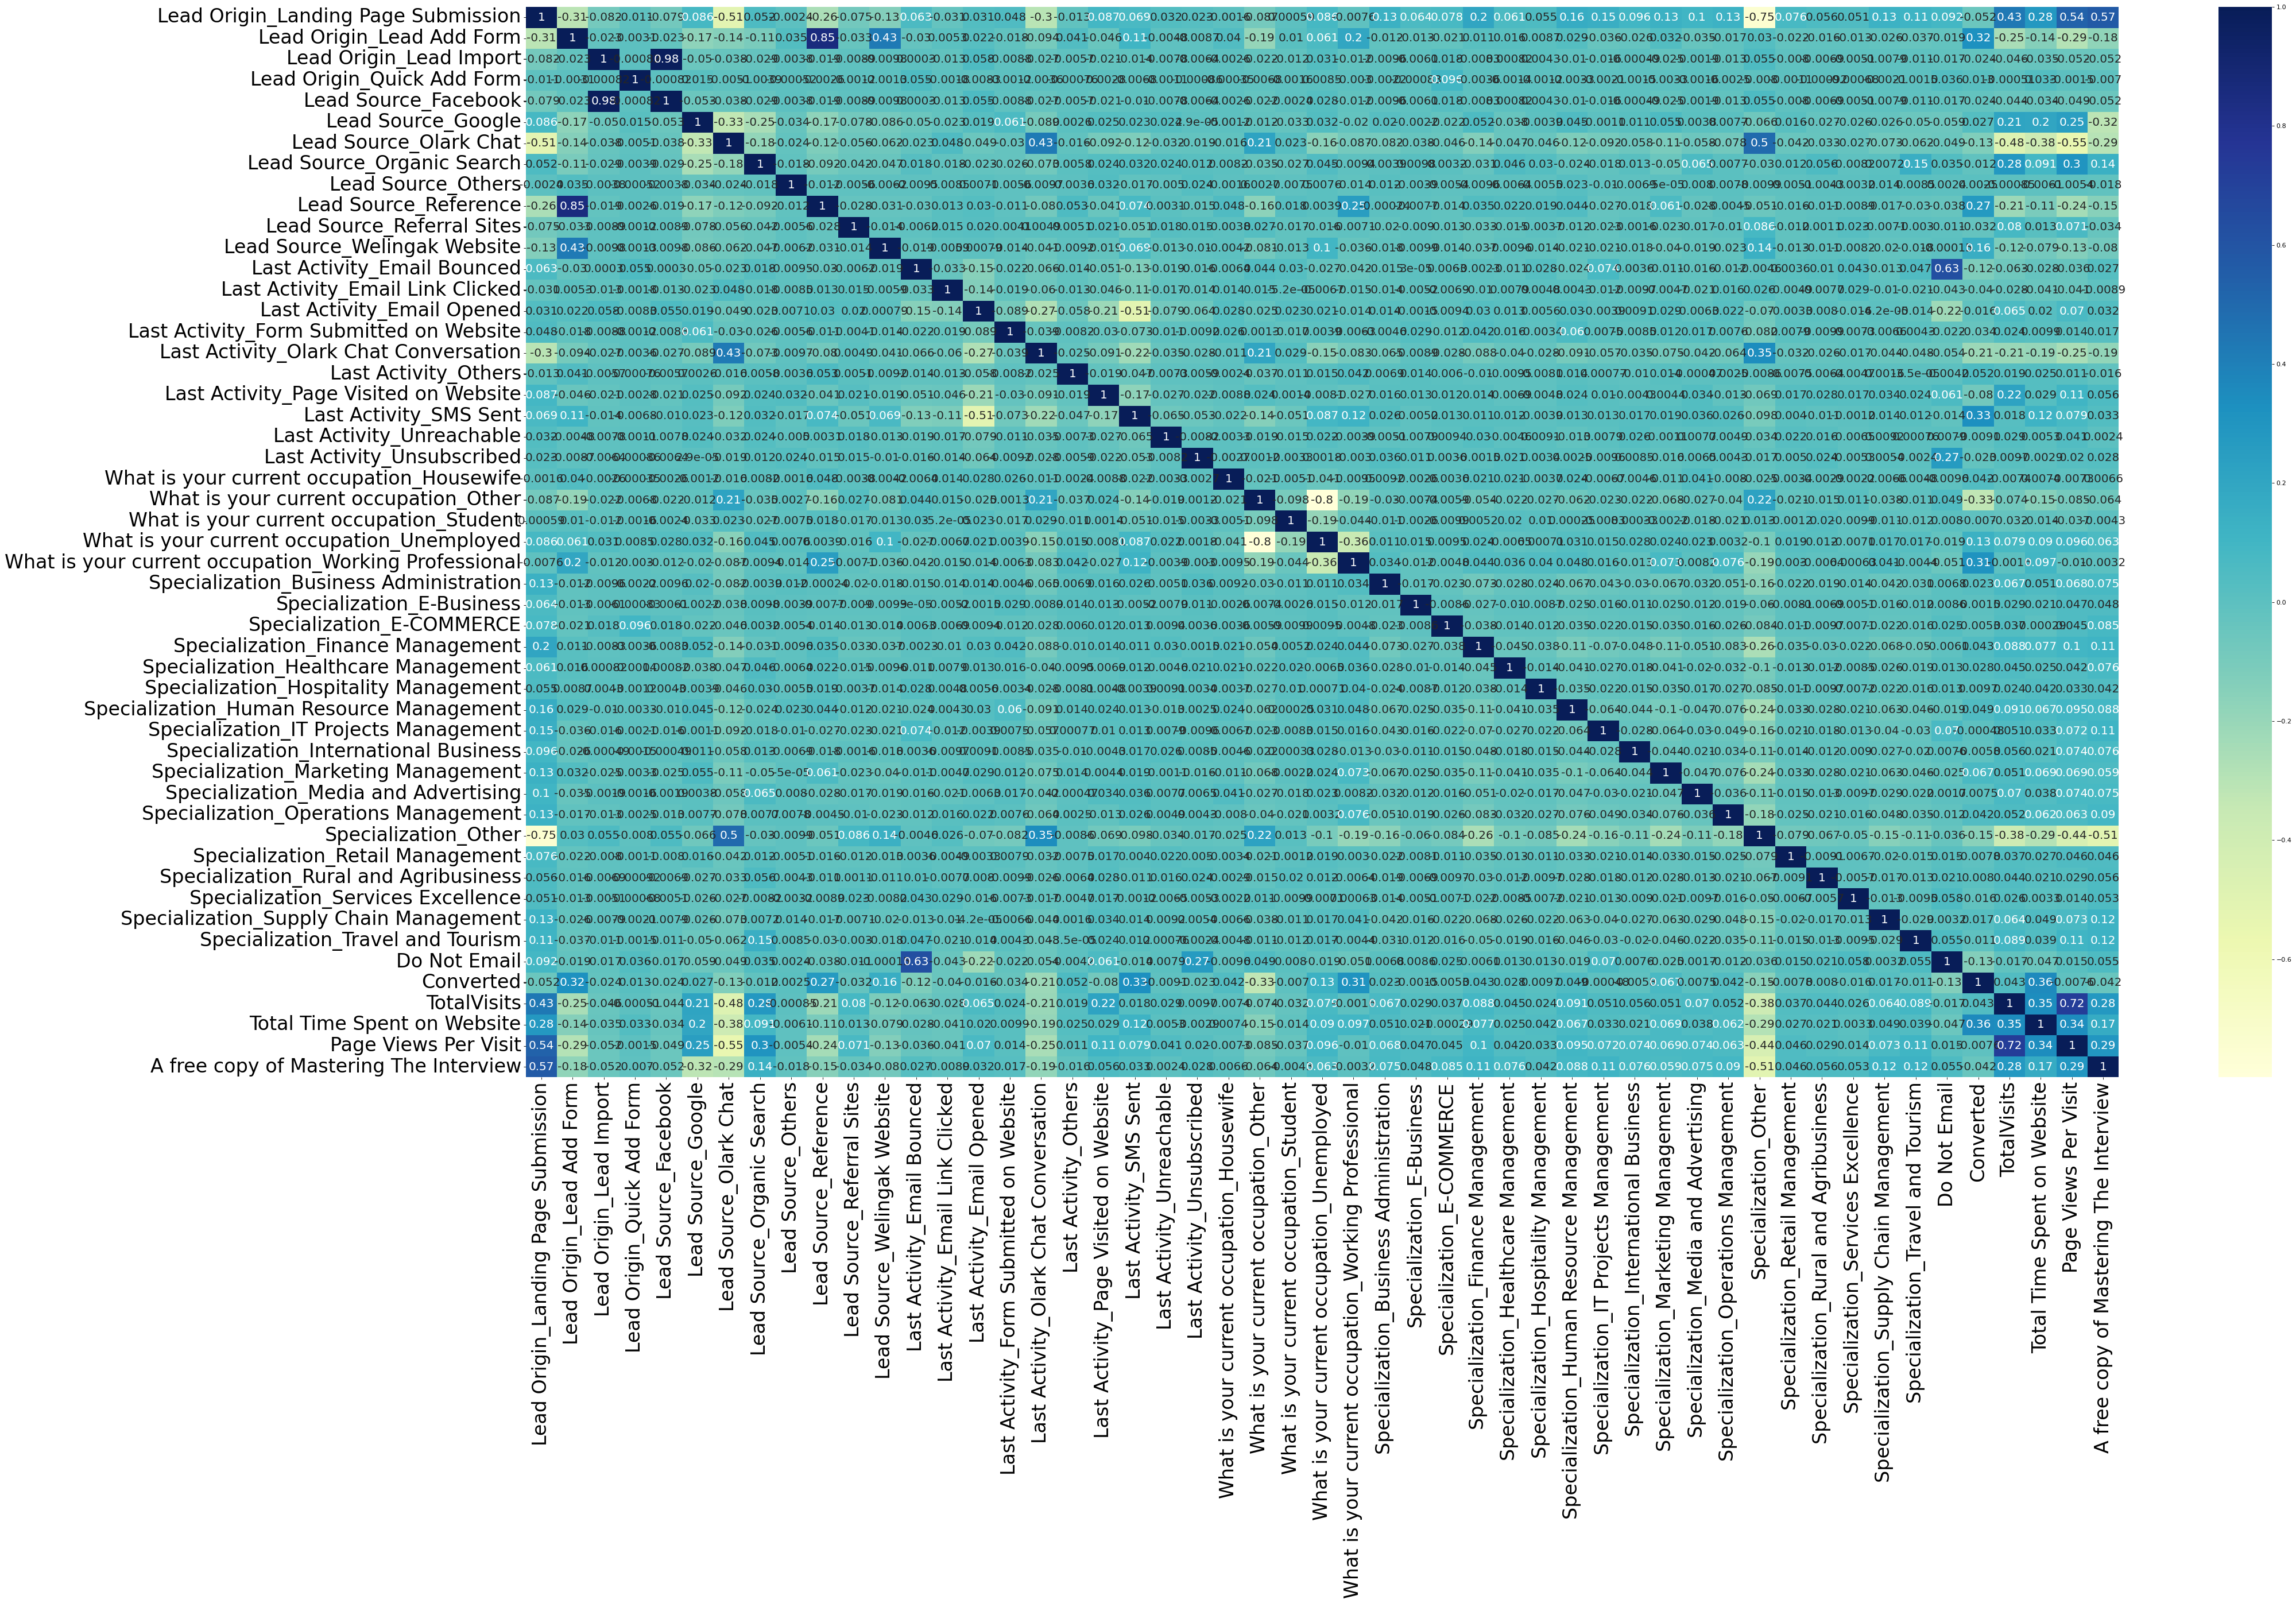

In [97]:
# Let's check the correlation coefficients to see which variables are highly correlated:-

plt.figure(figsize = (55, 35),dpi=80)
sns.heatmap(leads_df2.corr(), annot = True, cmap="YlGnBu",annot_kws={"size": 18})
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.tight_layout()
plt.show()

Observation

The heatmap clearly shows which all variable are multicollinear in nature, and which variable have high collinearity with the target variable. - We will refer this map for building the logistic model so as to validate different correlated values along with VIF & p-value, for identifying the correct variable to select/eliminate from the model.
From above heatmap we can see that:-

'Lead Source_Facebook' and 'Lead Origin_Lead Import' having higher correlation of 0.98.
'Do Not Email' and 'Last Activity_Email Bounced' having higher correlation.
'Lead Origin_Lead Add Form' and 'Lead Source_Referance' having higher correlation of 0.85.
'TotalVisits' and 'Page Views Per Visit' having correlation of 0.72.
'Lead Origin_Lead Add Form' ,'Lead Source_Welingak Website', 'Last Activity_SMS Sent' and 'What is your current Occupation_Working Professionals' having positive correlation with our target variable 'Converted'.

# Step 7: Model Building
Model Building using Stats Model & RFE

In [98]:
#Importing 'LogisticRegression' :-

from sklearn.linear_model import LogisticRegression

# Creating LogisticRegression Object called 'regressor':-

regressor = LogisticRegression()

# Using RFE for feature elimination

In [99]:
#Importing 'RFE' for feature selection:-

from sklearn.feature_selection import RFE

rfe = RFE(regressor)             # running RFE with 15 variables as output

rfe = rfe.fit(X_train, y_train)

In [100]:
#Displaying columns selected by RFE and their weights:-

list(zip(X_train.columns,rfe.support_,rfe.ranking_))

[('Lead Origin_Landing Page Submission', True, 1),
 ('Lead Origin_Lead Add Form', True, 1),
 ('Lead Origin_Lead Import', False, 18),
 ('Lead Origin_Quick Add Form', False, 13),
 ('Lead Source_Facebook', True, 1),
 ('Lead Source_Google', False, 3),
 ('Lead Source_Olark Chat', True, 1),
 ('Lead Source_Organic Search', False, 21),
 ('Lead Source_Others', True, 1),
 ('Lead Source_Reference', False, 26),
 ('Lead Source_Referral Sites', False, 2),
 ('Lead Source_Welingak Website', True, 1),
 ('Last Activity_Email Bounced', False, 12),
 ('Last Activity_Email Link Clicked', True, 1),
 ('Last Activity_Email Opened', True, 1),
 ('Last Activity_Form Submitted on Website', False, 14),
 ('Last Activity_Olark Chat Conversation', True, 1),
 ('Last Activity_Others', True, 1),
 ('Last Activity_Page Visited on Website', True, 1),
 ('Last Activity_SMS Sent', True, 1),
 ('Last Activity_Unreachable', True, 1),
 ('Last Activity_Unsubscribed', True, 1),
 ('What is your current occupation_Housewife', True, 1)

In [101]:
# Storing columns selected by RFE into 'col' and displaying it:-

col = X_train.columns[rfe.support_]
col

Index(['Lead Origin_Landing Page Submission', 'Lead Origin_Lead Add Form', 'Lead Source_Facebook', 'Lead Source_Olark Chat', 'Lead Source_Others', 'Lead Source_Welingak Website', 'Last Activity_Email Link Clicked', 'Last Activity_Email Opened', 'Last Activity_Olark Chat Conversation', 'Last Activity_Others', 'Last Activity_Page Visited on Website', 'Last Activity_SMS Sent', 'Last Activity_Unreachable', 'Last Activity_Unsubscribed', 'What is your current occupation_Housewife', 'What is your current occupation_Other', 'What is your current occupation_Student', 'What is your current occupation_Unemployed', 'What is your current occupation_Working Professional', 'Specialization_E-COMMERCE', 'Specialization_Hospitality Management', 'Specialization_Other', 'Specialization_Retail Management', 'Do Not Email', 'Total Time Spent on Website'], dtype='object')

In [102]:
# Displaying columns which are not selected by RFE:-

X_train.columns[~rfe.support_]

Index(['Lead Origin_Lead Import', 'Lead Origin_Quick Add Form', 'Lead Source_Google', 'Lead Source_Organic Search', 'Lead Source_Reference', 'Lead Source_Referral Sites', 'Last Activity_Email Bounced', 'Last Activity_Form Submitted on Website', 'Specialization_Business Administration', 'Specialization_E-Business', 'Specialization_Finance Management', 'Specialization_Healthcare Management', 'Specialization_Human Resource Management', 'Specialization_IT Projects Management', 'Specialization_International Business', 'Specialization_Marketing Management', 'Specialization_Media and Advertising', 'Specialization_Operations Management', 'Specialization_Rural and Agribusiness', 'Specialization_Services Excellence', 'Specialization_Supply Chain Management', 'Specialization_Travel and Tourism', 'TotalVisits', 'Page Views Per Visit', 'A free copy of Mastering The Interview'], dtype='object')

In [103]:
# Creating X_test dataframe with RFE selected variables:-

X_train_rfe = X_train[col]

# Using manual feature elimination
Running First Training Model

Model 1

Starting with all the columns selected by RFE .

In [104]:
#Importing required 'statsmodels' library:-

import statsmodels.api as sm

In [105]:
# Add a constant:-

X_train_sm = sm.add_constant(X_train_rfe)

# Building first fitted model:-

logm1 = sm.GLM(y_train,X_train_sm, family = sm.families.Binomial()).fit()

In [106]:
# Print a summary of the logistic regression model obtained:-

logm1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Converted   No. Observations:                 6363
Model:                            GLM   Df Residuals:                     6337
Model Family:                Binomial   Df Model:                           25
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2537.1
Date:                Thu, 17 Oct 2024   Deviance:                       5074.2
Time:                        08:35:34   Pearson chi2:                 7.07e+03
No. Iterations:                    21   Pseudo R-squ. (CS):             0.4127
Covariance Type:            nonrobust                                         
========================================================================================================================
                                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
const                                                   -0.1433      1.158     -0.124      0.902      -2.413       2.127
Lead Origin_Landing Page Submission                     -0.8936      0.132     -6.791      0.000      -1.152      -0.636
Lead Origin_Lead Add Form                                2.8690      0.213     13.476      0.000       2.452       3.286
Lead Source_Facebook                                    -0.6293      0.516     -1.218      0.223      -1.642       0.383
Lead Source_Olark Chat                                   1.1041      0.126      8.743      0.000       0.857       1.352
Lead Source_Others                                       1.0736      0.695      1.545      0.122      -0.288       2.436
Lead Source_Welingak Website                             3.2256      1.037      3.112      0.002       1.194       5.257
Last Activity_Email Link Clicked                         0.5971      0.269      2.222      0.026       0.070       1.124
Last Activity_Email Opened                               1.0603      0.167      6.358      0.000       0.733       1.387
Last Activity_Olark Chat Conversation                   -0.3177      0.227     -1.402      0.161      -0.762       0.126
Last Activity_Others                                     2.1297      0.505      4.216      0.000       1.140       3.120
Last Activity_Page Visited on Website                    0.6088      0.212      2.869      0.004       0.193       1.025
Last Activity_SMS Sent                                   2.2727      0.167     13.583      0.000       1.945       2.601
Last Activity_Unreachable                                1.2497      0.352      3.548      0.000       0.559       1.940
Last Activity_Unsubscribed                               2.0926      0.466      4.489      0.000       1.179       3.006
What is your current occupation_Housewife               21.7760   1.38e+04      0.002      0.999    -2.7e+04    2.71e+04
What is your current occupation_Other                   -2.2664      1.155     -1.963      0.050      -4.530      -0.003
What is your current occupation_Student                 -1.0222      1.174     -0.871      0.384      -3.323       1.279
What is your current occupation_Unemployed              -1.0897      1.152     -0.946      0.344      -3.348       1.168
What is your current occupation_Working Professional     1.3461      1.166      1.155      0.248      -0.939       3.631
Specialization_E-COMMERCE                                0.3267      0.310      1.053      0.292      -0.281       0.935
Specialization_Hospitality Management                   -0.9531      0.340     -2.806      0.005      -1.619      -0.287
Specialization_Other                                    -0

# VIF Check for multicollinearity : variance_inflation_factor

In [107]:
# Importing 'variance_inflation_factor' from 'statsmodels':-

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [108]:
# Creating dataframe called 'vif' containing names feature variables and their respective VIFs:-

vif = pd.DataFrame()
vif['Features'] = X_train_rfe.columns
vif['VIF'] = [variance_inflation_factor(X_train_rfe.values, i) for i in range(X_train_rfe.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
17,What is your current occupation_Unemployed,14.91
15,What is your current occupation_Other,8.37
0,Lead Origin_Landing Page Submission,7.51
7,Last Activity_Email Opened,5.99
21,Specialization_Other,4.82
11,Last Activity_SMS Sent,4.71
8,Last Activity_Olark Chat Conversation,2.74
18,What is your current occupation_Working Profes...,2.67
3,Lead Source_Olark Chat,2.39
1,Lead Origin_Lead Add Form,2.03


# Dropping insignificant column and updating the model

In [109]:
#Dropping 'What is your current occupation_Housewife' because of insignificant variable p-value=0.999(p>0.05):-

X_train_new = X_train_rfe.drop(["What is your current occupation_Housewife"], axis = 1)

# Model 2

In [110]:
# Add a constant:-

X_train_sm2 = sm.add_constant(X_train_new)

# Building second fitted model:-

logm2 = sm.GLM(y_train,X_train_sm2, family = sm.families.Binomial()).fit()

In [111]:
# Print a summary of the logistic regression model obtained:-

logm2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Converted   No. Observations:                 6363
Model:                            GLM   Df Residuals:                     6338
Model Family:                Binomial   Df Model:                           24
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2539.0
Date:                Thu, 17 Oct 2024   Deviance:                       5077.9
Time:                        08:35:35   Pearson chi2:                 7.07e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4123
Covariance Type:            nonrobust                                         
========================================================================================================================
                                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
const                                                    1.2368      0.869      1.423      0.155      -0.467       2.940
Lead Origin_Landing Page Submission                     -0.8868      0.131     -6.746      0.000      -1.144      -0.629
Lead Origin_Lead Add Form                                2.8738      0.213     13.497      0.000       2.456       3.291
Lead Source_Facebook                                    -0.6260      0.517     -1.212      0.226      -1.638       0.386
Lead Source_Olark Chat                                   1.1079      0.126      8.771      0.000       0.860       1.355
Lead Source_Others                                       1.0755      0.695      1.547      0.122      -0.287       2.438
Lead Source_Welingak Website                             3.2243      1.036      3.111      0.002       1.193       5.256
Last Activity_Email Link Clicked                         0.5981      0.268      2.228      0.026       0.072       1.124
Last Activity_Email Opened                               1.0612      0.166      6.379      0.000       0.735       1.387
Last Activity_Olark Chat Conversation                   -0.3166      0.226     -1.399      0.162      -0.760       0.127
Last Activity_Others                                     2.1304      0.505      4.217      0.000       1.140       3.120
Last Activity_Page Visited on Website                    0.6019      0.212      2.838      0.005       0.186       1.017
Last Activity_SMS Sent                                   2.2726      0.167     13.608      0.000       1.945       2.600
Last Activity_Unreachable                                1.2498      0.352      3.550      0.000       0.560       1.940
Last Activity_Unsubscribed                               2.0919      0.466      4.488      0.000       1.178       3.006
What is your current occupation_Other                   -3.6521      0.861     -4.240      0.000      -5.340      -1.964
What is your current occupation_Student                 -2.4084      0.887     -2.716      0.007      -4.146      -0.670
What is your current occupation_Unemployed              -2.4753      0.858     -2.884      0.004      -4.157      -0.793
What is your current occupation_Working Professional    -0.0397      0.876     -0.045      0.964      -1.757       1.678
Specialization_E-COMMERCE                                0.3215      0.311      1.034      0.301      -0.288       0.931
Specialization_Hospitality Management                   -0.9537      0.340     -2.808      0.005      -1.619      -0.288
Specialization_Other                                    -0.8685      0.125     -6.927      0.000      -1.114      -0.623
Specialization_Retail Management                        -0

In [112]:
# Calculating VIF for new model:-

vif = pd.DataFrame()
vif['Features'] = X_train_new.columns
vif['VIF'] = [variance_inflation_factor(X_train_new.values, i) for i in range(X_train_new.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
16,What is your current occupation_Unemployed,14.55
14,What is your current occupation_Other,8.20
0,Lead Origin_Landing Page Submission,7.43
7,Last Activity_Email Opened,5.90
20,Specialization_Other,4.80
11,Last Activity_SMS Sent,4.67
8,Last Activity_Olark Chat Conversation,2.72
17,What is your current occupation_Working Profes...,2.63
3,Lead Source_Olark Chat,2.39
1,Lead Origin_Lead Add Form,2.02


# Dropping insignificant column and updating the model

In [113]:
#Dropping 'Last Activity_Others' because of  p-value=0.01:-

X_train_new = X_train_new.drop(["Last Activity_Others"], axis = 1)

# Model 3

In [114]:
#Adding constant:-

X_train_sm3 = sm.add_constant(X_train_new)

# Create a third fitted model:-

logm3 = sm.GLM(y_train,X_train_sm3, family = sm.families.Binomial()).fit()

In [115]:
# Print a summary of the logistic regression model obtained:-

logm3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Converted   No. Observations:                 6363
Model:                            GLM   Df Residuals:                     6339
Model Family:                Binomial   Df Model:                           23
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2548.7
Date:                Thu, 17 Oct 2024   Deviance:                       5097.3
Time:                        08:35:36   Pearson chi2:                 6.90e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4106
Covariance Type:            nonrobust                                         
========================================================================================================================
                                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
const                                                    1.3786      0.861      1.601      0.109      -0.309       3.067
Lead Origin_Landing Page Submission                     -0.8853      0.131     -6.747      0.000      -1.142      -0.628
Lead Origin_Lead Add Form                                2.9062      0.212     13.688      0.000       2.490       3.322
Lead Source_Facebook                                    -0.6383      0.517     -1.234      0.217      -1.653       0.376
Lead Source_Olark Chat                                   1.1133      0.126      8.824      0.000       0.866       1.361
Lead Source_Others                                       1.0772      0.696      1.547      0.122      -0.288       2.442
Lead Source_Welingak Website                             3.1740      1.034      3.071      0.002       1.148       5.200
Last Activity_Email Link Clicked                         0.3819      0.260      1.466      0.143      -0.129       0.892
Last Activity_Email Opened                               0.8463      0.153      5.531      0.000       0.546       1.146
Last Activity_Olark Chat Conversation                   -0.5316      0.217     -2.451      0.014      -0.957      -0.107
Last Activity_Page Visited on Website                    0.3901      0.202      1.930      0.054      -0.006       0.786
Last Activity_SMS Sent                                   2.0607      0.154     13.403      0.000       1.759       2.362
Last Activity_Unreachable                                1.0374      0.346      2.996      0.003       0.359       1.716
Last Activity_Unsubscribed                               1.9127      0.462      4.139      0.000       1.007       2.818
What is your current occupation_Other                   -3.5876      0.854     -4.201      0.000      -5.262      -1.914
What is your current occupation_Student                 -2.3544      0.880     -2.677      0.007      -4.078      -0.630
What is your current occupation_Unemployed              -2.4042      0.851     -2.826      0.005      -4.072      -0.737
What is your current occupation_Working Professional     0.0403      0.869      0.046      0.963      -1.663       1.744
Specialization_E-COMMERCE                                0.3075      0.310      0.991      0.322      -0.301       0.916
Specialization_Hospitality Management                   -0.9702      0.340     -2.857      0.004      -1.636      -0.305
Specialization_Other                                    -0.8661      0.125     -6.919      0.000      -1.111      -0.621
Specialization_Retail Management                        -0.5473      0.346     -1.580      0.114      -1.226       0.131
Do Not Email                                            -1

In [116]:
# Calculating VIF for new model:-

vif = pd.DataFrame()
vif['Features'] = X_train_new.columns
vif['VIF'] = [variance_inflation_factor(X_train_new.values, i) for i in range(X_train_new.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
15,What is your current occupation_Unemployed,14.11
13,What is your current occupation_Other,8.01
0,Lead Origin_Landing Page Submission,7.43
7,Last Activity_Email Opened,5.60
19,Specialization_Other,4.80
10,Last Activity_SMS Sent,4.43
8,Last Activity_Olark Chat Conversation,2.64
16,What is your current occupation_Working Profes...,2.56
3,Lead Source_Olark Chat,2.39
1,Lead Origin_Lead Add Form,2.01


Observation

From model 'logm3' we can see that P-values of variables are significant and VIF values are below 3 . So we need not drop any more variables and we can proceed with making predictions using this model only considering model 'logm3' as final model.

# Making prediction on 'train' dataset based on final model

In [117]:
# Calculating predicted values of 'y_train':-

y_train_pred = logm3.predict(X_train_sm3)
                            
y_train_pred[:10] # Displaying 10 values

302     0.063507
6087    0.013690
1033    0.254935
7656    0.187030
3241    0.753543
5738    0.041512
7366    0.098236
3680    0.032293
4170    0.737026
43      0.059214
dtype: float64

In [118]:
# Reshaping :-

y_train_pred = y_train_pred.values.reshape(-1)
y_train_pred[:10]

array([0.06350657, 0.01369033, 0.25493522, 0.18702955, 0.75354266,
       0.04151192, 0.09823611, 0.03229307, 0.73702636, 0.05921407])

Creating a dataframe with the actual Converted flag and the predicted probabilities

In [119]:
# Creating dataframe 'y_train_pred_final' with actual and predicted :-

y_train_pred_final = pd.DataFrame({'Converted':y_train.values, 'Converted_Prob':y_train_pred})

# Adding column 'Prospect ID' for indexing:-

y_train_pred_final['Prospect ID'] = y_train.index

# Displaying head of created dataframe:-

y_train_pred_final.head()

,Converted,Converted_Prob,Prospect ID
0,0,0.063507,302
1,0,0.013690,6087
2,0,0.254935,1033
3,0,0.187030,7656
4,1,0.753543,3241


# Step 8: Finding Optimal Cutoff Point
    
Optimal cutoff probability is that probability where we get balanced sensitivity and specificity

In [120]:
# Let's create columns with different probability cutoffs :-
numbers = [float(x)/10 for x in range(10)]
for i in numbers:
    y_train_pred_final[i]= y_train_pred_final.Converted_Prob.map(lambda x: 1 if x > i else 0)
y_train_pred_final.head()

,Converted,Converted_Prob,Prospect ID,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
0,0,0.063507,302,1,0,0,0,0,0,0,0,0,0
1,0,0.013690,6087,1,0,0,0,0,0,0,0,0,0
2,0,0.254935,1033,1,1,1,0,0,0,0,0,0,0
3,0,0.187030,7656,1,1,0,0,0,0,0,0,0,0
4,1,0.753543,3241,1,1,1,1,1,1,1,1,0,0


In [121]:
#Importing 'metrics' library:-

from sklearn import metrics

# Now let's calculate accuracy sensitivity and specificity for various probability cutoffs.
cutoff_df = pd.DataFrame( columns = ['prob','accuracy','sensi','speci'])

from sklearn.metrics import confusion_matrix

# TP = confusion[1,1] # true positive 
# TN = confusion[0,0] # true negatives
# FP = confusion[0,1] # false positives
# FN = confusion[1,0] # false negatives

num = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in num:
    cm1 = metrics.confusion_matrix(y_train_pred_final.Converted, y_train_pred_final[i] )
    total1=sum(sum(cm1))
    accuracy = (cm1[0,0]+cm1[1,1])/total1
    
    speci = cm1[0,0]/(cm1[0,0]+cm1[0,1])
    sensi = cm1[1,1]/(cm1[1,0]+cm1[1,1])
    cutoff_df.loc[i] =[ i ,accuracy,sensi,speci]
print(cutoff_df)

     prob  accuracy     sensi     speci
0.0   0.0  0.381581  1.000000  0.000000
0.1   0.1  0.637278  0.978171  0.426938
0.2   0.2  0.760805  0.918863  0.663278
0.3   0.3  0.799151  0.847611  0.769250
0.4   0.4  0.816910  0.780478  0.839390
0.5   0.5  0.818168  0.707166  0.886658
0.6   0.6  0.805438  0.610791  0.925540
0.7   0.7  0.789408  0.532949  0.947649
0.8   0.8  0.760333  0.420099  0.970267
0.9   0.9  0.714286  0.268946  0.989072


In [122]:
#Setting plot style:-

sns.set(style = 'darkgrid')

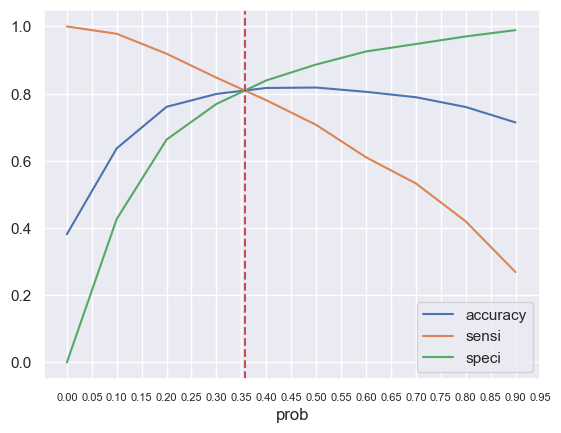

In [123]:
# Plotting accuracy, sensitivity and specificity for various probabilities:-


#plt.figure(figsize=(20,5))
cutoff_df.plot.line(x='prob', y=['accuracy','sensi','speci'])
plt.xticks(np.arange(0,1,step=0.05),size=8)
plt.axvline(x=0.358, color='r', linestyle='--') # additing axline

plt.show()

observtion :
    From the curve above, it seems that 0.358 is optimal cutoff point to take 

In [124]:
# Calculating 'final_predicted' based on 'Converted_Prob' using 0.358 cutoff point:-

y_train_pred_final['final_predicted'] = y_train_pred_final.Converted_Prob.map( lambda x: 1 if x > 0.358 else 0)

In [125]:
# Dropping the unnecessary columns:-

y_train_pred_final.drop([0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],axis = 1, inplace = True) 

In [126]:
#Displaying the head:-

y_train_pred_final.head() 

,Converted,Converted_Prob,Prospect ID,final_predicted
0,0,0.063507,302,0
1,0,0.013690,6087,0
2,0,0.254935,1033,0
3,0,0.187030,7656,0
4,1,0.753543,3241,1


# Assigning lead score to the leads based to prediction

In [127]:
# Assigning the 'Lead_Score' based on 'Converted_Prob' :-

y_train_pred_final['Lead_Score'] = y_train_pred_final.Converted_Prob.map( lambda x: round(x*100))

In [128]:
# Selecting only important columns and displaying head of dataframe:-

y_train_pred_final[['Converted','Converted_Prob','Prospect ID','final_predicted','Lead_Score']].head()

,Converted,Converted_Prob,Prospect ID,final_predicted,Lead_Score
0,0,0.063507,302,0,6
1,0,0.013690,6087,0,1
2,0,0.254935,1033,0,25
3,0,0.187030,7656,0,19
4,1,0.753543,3241,1,75


# Step 9:Model Evaluation
Confusion Matrix

In [129]:
#Importing 'metrics' library:-

from sklearn import metrics

# Confusion matrix:-

confusion = metrics.confusion_matrix(y_train_pred_final.Converted, y_train_pred_final.final_predicted)
print(confusion)

[[3193  742]
 [ 464 1964]]


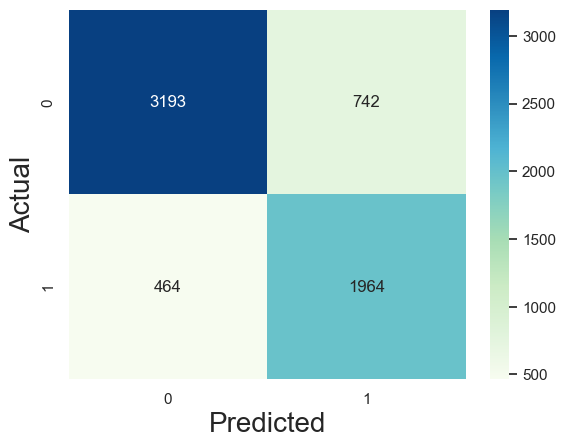

In [133]:
#Importing library to plot confusion matrix:-
from sklearn.metrics import confusion_matrix

# Plotting confusion matrix:-
sns.heatmap(confusion, annot=True,fmt='g',cmap='GnBu')
plt.xlabel('Predicted',fontsize=20)
plt.ylabel('Actual',fontsize=20)
plt.show()

In [134]:
# Actual/Predicted     not_converted   converted
        # not_converted        3170          765
        # converted            463          1965 

In [135]:
# Check the overall accuracy:-

metrics.accuracy_score(y_train_pred_final.Converted, y_train_pred_final.final_predicted)

0.8104667609618105

In [136]:
TP = confusion[1,1] # true positive 
TN = confusion[0,0] # true negatives
FP = confusion[0,1] # false positives
FN = confusion[1,0] # false negatives

In [137]:
# Checking the sensitivity of our logistic regression model:-

TP / float(TP+FN)

0.8088962108731467

In [138]:
# Calculating specificity:-

TN / float(TN+FP)

0.8114358322744599

In [139]:
# Calculate False Postive Rate - predicting conversion when customer does not have convert:-

print(FP/ float(TN+FP))

0.18856416772554002


In [140]:
# positive predictive value :-

print (TP / float(TP+FP))

0.7257945306725795


In [142]:
 #Negative predictive value:-

print (TN / float(TN+ FN))

0.873120043751709


# Precision and Recall

Precision
TP / TP + FP

In [143]:
confusion[1,1]/(confusion[0,1]+confusion[1,1])

0.7257945306725795

# Recall

TP / TP + FN

In [144]:
# Calculating 'Recall' :-

confusion[1,1]/(confusion[1,0]+confusion[1,1])

0.8088962108731467

Using sklearn utilities for the same

In [145]:
#Importing 'precision_score' and 'recall_score':_

from sklearn.metrics import precision_score, recall_score

In [146]:
# Calculating Precision value:-

precision_score(y_train_pred_final.Converted, y_train_pred_final.final_predicted)

0.7257945306725795

In [147]:
#Calculating Recall value:-

recall_score(y_train_pred_final.Converted, y_train_pred_final.final_predicted)

0.8088962108731467

Observation

We have the following values for the Train Data:

Accuracy : 80%,
Sensitivity : 80%,
Specificity : 81%,
Pricision: 72%,
Recall: 80%

# Step 10: Plotting the ROC Curve

An ROC curve demonstrates several things:
    

It shows the tradeoff between sensitivity and specificity (any increase in sensitivity will be accompanied by a decrease in specificity).

The closer the curve follows the left-hand border and then the top border of the ROC space, the more accurate the test.

The closer the curve comes to the 45-degree diagonal of the ROC space, the less accurate the test.

In [148]:
def draw_roc( actual, probs ):
    fpr, tpr, thresholds = metrics.roc_curve( actual, probs,
                                              drop_intermediate = False )
    auc_score = metrics.roc_auc_score( actual, probs )
    plt.figure(figsize=(5, 5))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score )
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()

    return None

In [149]:
fpr, tpr, thresholds = metrics.roc_curve( y_train_pred_final.Converted, y_train_pred_final.Converted_Prob, drop_intermediate = False )

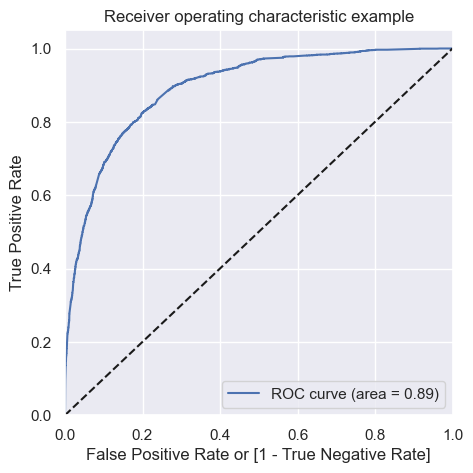

In [150]:
draw_roc(y_train_pred_final.Converted, y_train_pred_final.Converted_Prob)

Observation

We are getting a good value of 0.89 indicating a good predictive model.As ROC Curve should be a value close to 1.



# Precision and recall tradeoff

In [151]:
# Importing required library for 'precision_recall_curve' :-

from sklearn.metrics import precision_recall_curve

In [152]:
p, r, thresholds = precision_recall_curve(y_train_pred_final.Converted, y_train_pred_final.Converted_Prob)

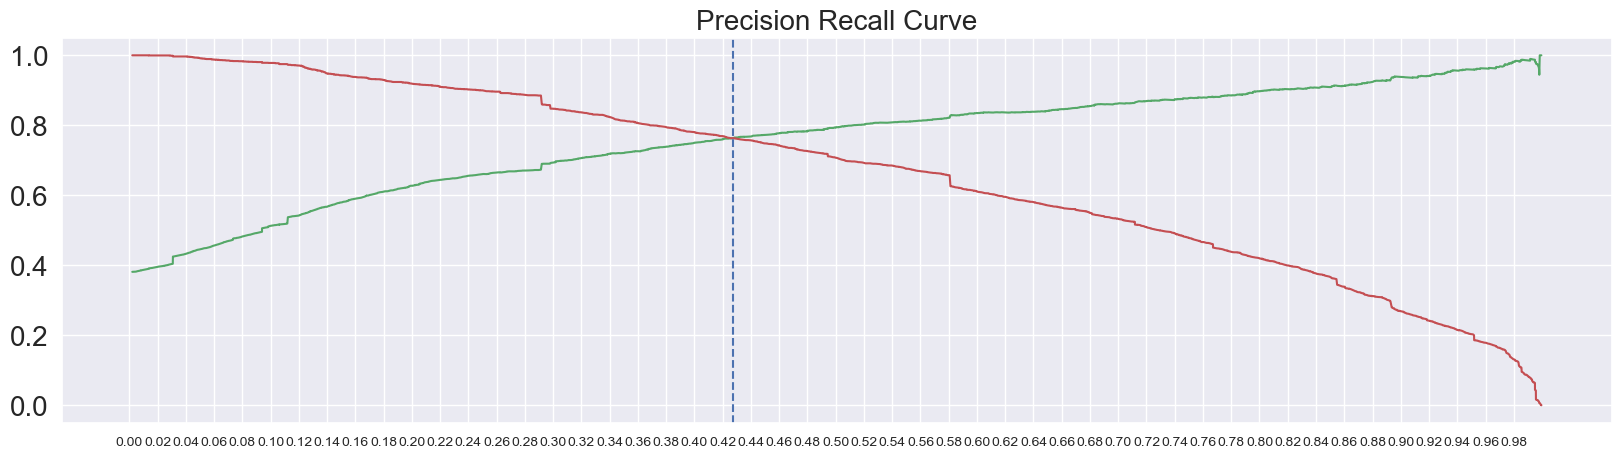

In [153]:
plt.figure(figsize=(20,5))
plt.plot(thresholds, p[:-1], "g-")
plt.plot(thresholds, r[:-1], "r-")
plt.title('Precision Recall Curve',fontsize=20)
plt.axvline(x=0.427, color='b', linestyle='--') # additing axline
plt.xticks(np.arange(0,1,step=0.02),size=10)
plt.yticks(size=20)

plt.show()


Observation

From above above 'precision_recall_curve' we can see that cutoff point is 0.427.

# Now using this threshold value from 'Precision Recall Tradeoff Curve' for Data Evaluation

In [154]:
# plotting the Train dataset again with 0.427 as cutoff:-

y_train_pred_final['final_predicted_2'] = y_train_pred_final['Converted_Prob'].map( lambda x: 1 if x > 0.427 else 0)
y_train_pred_final.head() # Displaying head 

,Converted,Converted_Prob,Prospect ID,final_predicted,Lead_Score,final_predicted_2
0,0,0.063507,302,0,6,0
1,0,0.013690,6087,0,1,0
2,0,0.254935,1033,0,25,0
3,0,0.187030,7656,0,19,0
4,1,0.753543,3241,1,75,1


In [155]:
# Confusion matrix:-

confusion_2 = metrics.confusion_matrix(y_train_pred_final.Converted, y_train_pred_final.final_predicted_2)
print(confusion_2)

[[3360  575]
 [ 575 1853]]


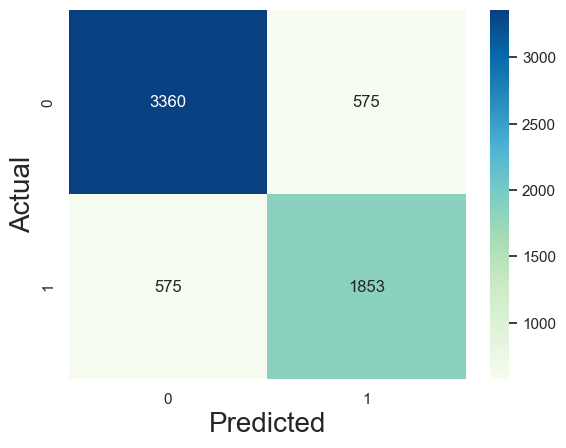

In [156]:
# Plotting confusion matrix:-
sns.heatmap(confusion_2, annot=True,fmt='g',cmap='GnBu')
plt.xlabel('Predicted',fontsize=20)
plt.ylabel('Actual',fontsize=20)
plt.show()

In [157]:
# Check the overall accuracy:-

metrics.accuracy_score(y_train_pred_final.Converted, y_train_pred_final.final_predicted_2)

0.8192676410498193

In [158]:
TP = confusion_2[1,1] # true positive 
TN = confusion_2[0,0] # true negatives
FP = confusion_2[0,1] # false positives
FN = confusion_2[1,0] # false negatives

In [159]:
# Checking the sensitivity of our logistic regression model:-

TP / float(TP+FN)

0.7631795716639209

In [160]:
# Calculating specificity:-

TN / float(TN+FP)

0.8538754764930114

In [161]:
# positive predictive value :-

print (TP / float(TP+FP))

0.7631795716639209


In [162]:
# Negative predictive value:-

print (TN / float(TN+ FN))

0.8538754764930114


In [163]:
# Pricision:-

confusion_2[1,1]/(confusion_2[0,1]+confusion_2[1,1])

0.7631795716639209

In [164]:
# Calculating 'Recall' :-

confusion_2[1,1]/(confusion_2[1,0]+confusion_2[1,1])

0.7631795716639209

# Observation

By using the Precision - Recall trade off curve cut off point True Positive number has decrease and True Negative number has increase

Thus, we cannot use Precision-Recall trade-off method as it reduced True Positive so 'Recall'/'sensitivity' decreased for this point We have to increase Sensitivity Recall value to increase True Positives. Thus we will use 0.358 as optimal cutoff point.

# Step 11: Making predictions on the test set

In [165]:
# Applying 'transform' to scale the 'test' data set:-

X_test[['TotalVisits','Total Time Spent on Website','Page Views Per Visit']] = scaler.transform(X_test[['TotalVisits','Total Time Spent on Website','Page Views Per Visit']])

In [166]:
# Predicting using values used by the final model i.e. logm3:-

test_col = X_train_sm3.columns

X_test=X_test[test_col[1:]]
# Adding constant variable to test dataframe:-
X_test = sm.add_constant(X_test)

X_test.info() #Displaying info about columns

<class 'pandas.core.frame.DataFrame'>
Index: 2727 entries, 6906 to 6219
Data columns (total 24 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   const                                                 2727 non-null   float64
 1   Lead Origin_Landing Page Submission                   2727 non-null   int32  
 2   Lead Origin_Lead Add Form                             2727 non-null   int32  
 3   Lead Source_Facebook                                  2727 non-null   int32  
 4   Lead Source_Olark Chat                                2727 non-null   int32  
 5   Lead Source_Others                                    2727 non-null   int32  
 6   Lead Source_Welingak Website                          2727 non-null   int32  
 7   Last Activity_Email Link Clicked                      2727 non-null   int32  
 8   Last Activity_Email Opened                            2727 n

# Making Predictions on the X_test dataset using the final model

In [167]:
# Predicting on test data set using final model :-

y_test_pred = logm3.predict(X_test)

In [168]:
# Checking top 10 rows:-

y_test_pred[:10]

6906    0.901967
1873    0.213308
771     0.129527
4495    0.149767
9061    0.582200
4929    0.433354
2308    0.101997
1034    0.080868
9033    0.126503
7008    0.914014
dtype: float64

In [169]:
# Converting y_test_pred to a dataframe :-

y_pred_1 = pd.DataFrame(y_test_pred)

In [170]:
# Let's see the head
y_pred_1.head()

,0
6906,0.901967
1873,0.213308
771,0.129527
4495,0.149767
9061,0.582200


In [171]:
# Converting y_test to dataframe:-

y_test_df = pd.DataFrame(y_test)

In [172]:
# Putting 'Prospect ID' to index:-

y_test_df['Prospect ID'] = y_test_df.index

# Removing index for both dataframes to append them side by side :-

y_pred_1.reset_index(drop=True, inplace=True)
y_test_df.reset_index(drop=True, inplace=True)

In [173]:
# Appending y_test_df and y_pred_1:-

y_pred_final = pd.concat([y_test_df, y_pred_1],axis=1)

In [174]:
# Displaying head of 'y_pred_final' :-

y_pred_final.head()

,Converted,Prospect ID,0
0,1,6906,0.901967
1,0,1873,0.213308
2,0,771,0.129527
3,0,4495,0.149767
4,1,9061,0.582200


In [175]:
# Renaming the column '0' as 'Converted_Prob':-

y_pred_final= y_pred_final.rename(columns={ 0 : 'Converted_Prob'})

In [176]:
# Rearranging the columns:-

y_pred_final = y_pred_final[['Prospect ID','Converted','Converted_Prob']]

In [177]:
# Let's see the head of y_pred_final:-

y_pred_final.head()

,Prospect ID,Converted,Converted_Prob
0,6906,1,0.901967
1,1873,0,0.213308
2,771,0,0.129527
3,4495,0,0.149767
4,9061,1,0.582200


In [178]:
#Assigning 'Lead Score' to dataframe 'y_pred_final':-

y_pred_final['Lead_Score'] = y_pred_final.Converted_Prob.map( lambda x: round(x*100))

In [179]:
y_pred_final.head()


,Prospect ID,Converted,Converted_Prob,Lead_Score
0,6906,1,0.901967,90
1,1873,0,0.213308,21
2,771,0,0.129527,13
3,4495,0,0.149767,15
4,9061,1,0.582200,58


# Using Cutoff point of 0.357 from Sentivity - Specificity - Accuracy plot cut-off point

In [180]:
# Calculating 'final_Predicted' based on 'Converted_Prob' for cutoff point 0.357:-

y_pred_final['final_Predicted'] = y_pred_final.Converted_Prob.map(lambda x: 1 if x > 0.357 else 0)

In [181]:
# Displaying the head of 'y_pred_final' dataframe:-

y_pred_final.head()

,Prospect ID,Converted,Converted_Prob,Lead_Score,final_Predicted
0,6906,1,0.901967,90,1
1,1873,0,0.213308,21,0
2,771,0,0.129527,13,0
3,4495,0,0.149767,15,0
4,9061,1,0.582200,58,1


# Test model evaluation

In [182]:
# Checking the overall accuracy:-

metrics.accuracy_score(y_pred_final.Converted, y_pred_final.final_Predicted)

0.8063806380638063

# Confusion Matrix

In [183]:
# Calculating confusion matrix for test data:-

confusion2 = metrics.confusion_matrix(y_pred_final.Converted, y_pred_final.final_Predicted )
confusion2

array([[1346,  314],
       [ 214,  853]], dtype=int64)

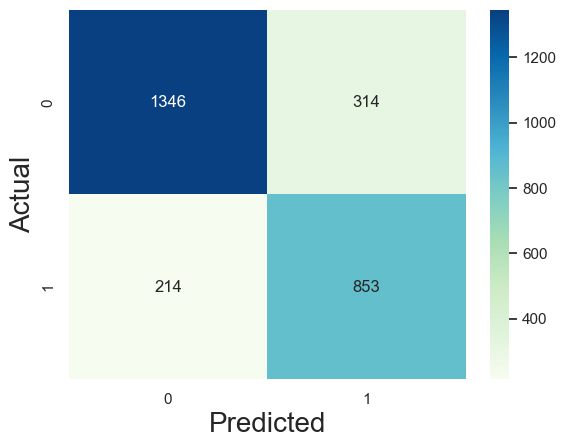

In [184]:
# Plotting confusion matrix:-
sns.heatmap(confusion2, annot=True,fmt='g',cmap='GnBu')
plt.xlabel('Predicted',fontsize=20)
plt.ylabel('Actual',fontsize=20)
plt.show()

In [185]:
TP = confusion2[1,1] # true positive 
TN = confusion2[0,0] # true negatives
FP = confusion2[0,1] # false positives
FN = confusion2[1,0] # false negatives

In [186]:
# Let's see the sensitivity of our logistic regression model:-

TP / float(TP+FN)

0.7994376757263355

In [187]:
# Let us calculate specificity:-

TN / float(TN+FP)

0.810843373493976

In [188]:
# Calculate False Postive Rate - predicting conversion when customer does not have convert:-

print(FP/ float(TN+FP))

0.1891566265060241


In [189]:
# positive predictive value :-

print (TP / float(TP+FP))

0.7309340188517567


In [190]:
# Negative predictive value:-

print (TN / float(TN+ FN))

0.8628205128205129


# Precision and Recall

In [191]:
# Calculating 'precision_score':-

precision_score(y_pred_final.Converted, y_pred_final.final_Predicted)

0.7309340188517567

In [192]:
#Calculating 'recall_score':-

recall_score(y_pred_final.Converted, y_pred_final.final_Predicted)

0.7994376757263355

Observation

The sensitivity value for test data is 80% while for train data is also 80% . The accuracy values is ~ 80%. Which shows that model is performing well for test data set also

# Determining top feature based on final model (logm5)

In [193]:
# Displaying parameters obtained by final model 'logm5':-

pd.options.display.float_format = '{:.2f}'.format # Setting format option
logm3.params[1:]

Lead Origin_Landing Page Submission                    -0.89
Lead Origin_Lead Add Form                               2.91
Lead Source_Facebook                                   -0.64
Lead Source_Olark Chat                                  1.11
Lead Source_Others                                      1.08
Lead Source_Welingak Website                            3.17
Last Activity_Email Link Clicked                        0.38
Last Activity_Email Opened                              0.85
Last Activity_Olark Chat Conversation                  -0.53
Last Activity_Page Visited on Website                   0.39
Last Activity_SMS Sent                                  2.06
Last Activity_Unreachable                               1.04
Last Activity_Unsubscribed                              1.91
What is your current occupation_Other                  -3.59
What is your current occupation_Student                -2.35
What is your current occupation_Unemployed             -2.40
What is your current occ

In [194]:
#Getting a relative coeffient value for all the features wrt the feature with the highest coefficient:-

top_feature = logm3.params[1:]
top_feature = 100.0 * (top_feature / top_feature.max())
top_feature

Lead Origin_Landing Page Submission                     -27.89
Lead Origin_Lead Add Form                                91.56
Lead Source_Facebook                                    -20.11
Lead Source_Olark Chat                                   35.07
Lead Source_Others                                       33.94
Lead Source_Welingak Website                            100.00
Last Activity_Email Link Clicked                         12.03
Last Activity_Email Opened                               26.66
Last Activity_Olark Chat Conversation                   -16.75
Last Activity_Page Visited on Website                    12.29
Last Activity_SMS Sent                                   64.92
Last Activity_Unreachable                                32.68
Last Activity_Unsubscribed                               60.26
What is your current occupation_Other                  -113.03
What is your current occupation_Student                 -74.18
What is your current occupation_Unemployed             

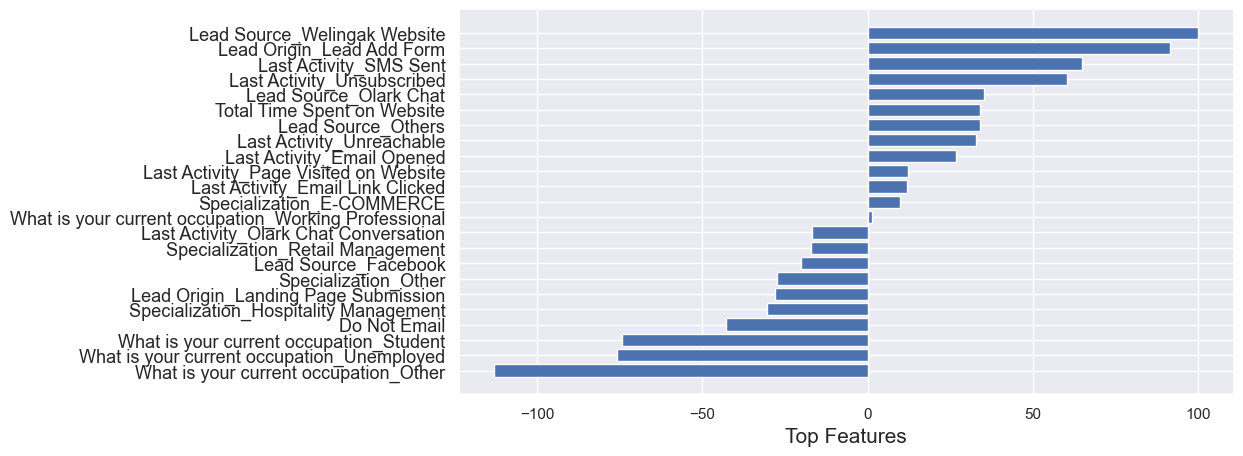

In [195]:
# Plotting the feature variables based on their relative importance:-

top_feature_sort = np.argsort(top_feature,kind='quicksort',order='list of str')

pos = np.arange(top_feature_sort.shape[0]) + .5

fig1 = plt.figure(figsize=(10,5))
ax = fig1.add_subplot(1, 1, 1)
ax.barh(pos, top_feature[top_feature_sort])
ax.set_yticks(pos)
ax.set_yticklabels(np.array(X_train_new.columns)[top_feature_sort], fontsize=13)
ax.set_xlabel('Top Features', fontsize=15)
plt.show()

Final model line equation :-
    
Converted = 0.261843 + 3.15 X Lead Source_Welingak Website + 2.98 X Lead Origin_Lead Add Form + 2.39 X What is your current occupation_Working Professional + 1.45 X Last Activity_Unsubscribed + 1.38 X Last Activity_SMS Sent + 1.17 X Lead Source_Olark Chat + 1.07 X Total Time Spent on Website - 0.87 X Lead Origin_Landing Page Submission - 0.87 X Specialization_Other - 0.96 X Specialization_Hospitality Management - 1.19 X What is your current occupation_Other - 1.22 X Last Activity_Olark Chat Conversation

# Final Observation
Evaluation Metrics for the train Dataset:-

Accuracy :0.80

Sensitivity:~0.80

Specificity:0.81

Precision: 0.72

Recall: 0.80

Evaluation Metrics for the test Dataset:-

Accuracy : 0.80

Sensitivity: ~ 0.80

Specificity: 0.80

Precision: 0.72

Recall: 0.80

Recommendation

To improve the potential lead conversion rate X-Education will have to mainly focus important features responsible for good conversion rate are :-

Lead Source_Welingak Website : As conversion rate is higher for those leads who got to know about course from 'Welingak Website',so company can focus on this website to get more number of potential leads.

Lead Origin_Lead Add Form: Leads who have engaged through 'Lead Add Form' having higher conversion rate so company can focus on it to get more number of leads cause have a higher chances of getting converted.

What is your current occupation_Working Professional : The lead whose occupation is 'Working Professional' having higher lead conversion rate ,company should focus on working professionals nad try to get more number of leads.

Last Activity_SMS Sent: Lead whose last activity is sms sent can be potential lead for company.

Total Time Spent on website: Leads spending more time on website can be our potential lead.